In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers.experimental.preprocessing import Normalization
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import hvplot.pandas
import panel as pn
import holoviews as hv
hv.extension('bokeh')
import matplotlib.pyplot as plt

In [21]:
tf.__version__
 

'2.10.0'

In [35]:
import os
path_data = '.'

In [36]:
root_logdir = os.path.join(os.curdir, "tf_training_logs")
tensorboard_cb = keras.callbacks.TensorBoard(root_logdir)

In [37]:
#HZS_02_17_2026: four used DCR 25 cmstudies for training:

dfin_in_base1 = pd.read_csv(os.path.join(path_data, '.\dcr_base_1_input.csv'), index_col=0, parse_dates=True)
dfin_in_base2 = pd.read_csv(os.path.join(path_data, '.\dcr_base_2_input.csv'), index_col=0, parse_dates=True)
dfin_in_base3 = pd.read_csv(os.path.join(path_data, '.\dcr_base_3_input.csv'), index_col=0, parse_dates=True)
dfin_in_base4 = pd.read_csv(os.path.join(path_data, '.\dcr_base_4_input.csv'), index_col=0, parse_dates=True)

dfout_out_base1 = pd.read_csv(os.path.join(path_data, '.\dcr_base_1_output.csv'), index_col=0, parse_dates=True)
dfout_out_base2 = pd.read_csv(os.path.join(path_data, '.\dcr_base_2_output.csv'), index_col=0, parse_dates=True)
dfout_out_base3 = pd.read_csv(os.path.join(path_data, '.\dcr_base_3_output.csv'), index_col=0, parse_dates=True)
dfout_out_base4 = pd.read_csv(os.path.join(path_data, '.\dcr_base_4_output.csv'), index_col=0, parse_dates=True)

In [43]:
#output_locations = ['CVP_INTAKE', 'MIDR_INTAKE', 'OLDR_CCF', 'ROLD024', 'ROLD034','RSAC081', 'RSAC092', 'RSAC054','RSAN007', 'RSAN018', 'SLMZU011', 'VICT_INTAKE']
output_locations = ['ROLD024','RSAN018', 'RSAC092','RSAC081', 'RSAC054']
#output_locations = [ 'SLMZU011', 'VICT_INTAKE','RSAN007']
calib_slice = slice('1940', '2021')
valid_slice = slice('1923', '1939')

In [44]:
# Define Sequential model with 3 layers
NFEATURES = 126  # (8 + 10)*7


def build_model(nhidden1=8, nhidden2=2, act_func='sigmoid'):
    model = keras.Sequential(
        [
            layers.Input(shape=(NFEATURES)),
            layers.Dense(nhidden1, activation=act_func),
            layers.Dense(nhidden2, activation=act_func),
            layers.Dense(1, activation=keras.activations.linear)
        ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")
    return model

In [45]:
import annutilsr
import annutils
import annutils_x

The next code is while we want to shuffle the scaled data before training.

Please do not run the next one!

In [ ]:
import numpy as np
import pandas as pd
import keras
import annutilsr
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

np.random.seed(1)  # For reproducibility

calib_prop = 0.8  # 80% of the data for calibration

for location in output_locations:
    output_location = f'{location}_EC'

    (xallc, yallc), (xallv, yallv), xscaler, yscaler = annutilsr.create_training_sets([dfin_in_base1, dfin_in_base2, dfin_in_base3, dfin_in_base4],
                                      [dfout_out_base1[[output_location]],
                                       dfout_out_base2[[output_location]],
                                       dfout_out_base3[[output_location]]],
                                       dfout_out_base4[[output_location]]],
                                      calib_slice=slice('1940', '2021'),
                                      valid_slice=slice('1921', '1939'))

    print("Dimensions of xallc:", xallc.shape)
    
    vset = np.random.rand(xallc.shape[0])
    val_mask = (vset >= calib_prop) & (vset < (calib_prop + 0.2))
    train_mask = vset < calib_prop

    xallc_c = xallc[train_mask]
    yallc_c = yallc[train_mask]
    xallc_v = xallc[val_mask]
    yallc_v = yallc[val_mask]


    print("Dimensions of xallc_c:", xallc_c.shape)
    print("Dimensions of yallc_c:", yallc_c.shape)
    print("Dimensions of xallc_v:", xallc_v.shape)
    print("Dimensions of yallc_v:", yallc_v.shape)

    model = build_model(nhidden1=8, nhidden2=2, act_func='sigmoid')
    model.compile(optimizer='adam', loss='mse')
    model.summary()

    history = model.fit(
        xallc_c,
        yallc_c,
        #epochs=20000,
        epochs=300,
        #epochs=10,
        batch_size=128,
        validation_data=(xallc_v, yallc_v),
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=1000, mode="min", restore_best_weights=True)]
    )
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Over Epochs for {location}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    
    annutilsr.save_model(location, model, xscaler, yscaler)


The following code is searching for some hyperparameter such as optimal number of Epochs and optimal number of Batch Size!

In [ ]:
import numpy as np
import pandas as pd
import keras
import annutilsr
import warnings
import matplotlib.pyplot as plt
import xlsxwriter

warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
np.random.seed(1)  # For reproducibility

calib_prop = 0.8  # 80% of the data for calibration

# Define batch sizes and epoch values to test
batch_sizes = [16, 32, 64, 128, 256]
epoch_values = [1000, 2000, 3000, 5000, 8000, 10000]

# Create an Excel writer object to save results in an Excel file
excel_filename = "batch_epochs_results.xlsx"
with pd.ExcelWriter(excel_filename, engine='xlsxwriter') as writer:
    for location in output_locations:
        output_location = f'{location}_EC'

        # Prepare training and validation datasets
        (xallc, yallc), (xallv, yallv), xscaler, yscaler = annutilsr.create_training_sets(
            [dfin_in_dcp_naa, dfin_in_smscg_naa, dfin_in_dcp_pa6k],
            [dfout_out_dcp_naa[[output_location]],
             dfout_out_smscg_naa[[output_location]],
             dfout_out_dcp_pa6k[[output_location]]],
            calib_slice=slice('1940', '2021'),
            valid_slice=slice('1922', '1939')
        )

        print(f"\n### Training for Location: {location} ###\n")

        vset = np.random.rand(xallc.shape[0])
        val_mask = (vset >= calib_prop) & (vset < (calib_prop + 0.2))
        train_mask = vset < calib_prop

        xallc_c = xallc[train_mask]
        yallc_c = yallc[train_mask]
        xallc_v = xallc[val_mask]
        yallc_v = yallc[val_mask]

        # Track the best configuration
        best_val_loss = float('inf')
        best_batch_size = None
        best_epochs = None
        best_model = None

        # Store batch size and epoch results
        results = []

        for epochs in epoch_values:
            for batch_size in batch_sizes:
                print(f"\nTraining with batch size: {batch_size}, epochs: {epochs}")

                # Build and compile model
                model = build_model(nhidden1=8, nhidden2=2, act_func='sigmoid')
                model.compile(optimizer='adam', loss='mse')

                # Train model
                history = model.fit(
                    xallc_c, yallc_c,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(xallc_v, yallc_v),
                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=1000, mode="min", restore_best_weights=True)],
                    verbose=0  # Suppress detailed output
                )

                # Get the final training and validation loss values
                final_loss = history.history['loss'][-1]
                final_val_loss = history.history['val_loss'][-1]

                # Store the results
                results.append((batch_size, epochs, final_loss, final_val_loss))

                print(f"Batch Size {batch_size}, Epochs {epochs}: Loss = {final_loss:.6f}, Val_Loss = {final_val_loss:.6f}")

                # Check if this model is the best so far
                if final_val_loss < best_val_loss:
                    best_val_loss = final_val_loss
                    best_batch_size = batch_size
                    best_epochs = epochs
                    best_model = model  # Store the best model

        # Create a DataFrame for the results
        df_results = pd.DataFrame(results, columns=["Batch Size", "Epochs", "Loss", "Validation Loss"])

        # Save results in an Excel sheet for this location
        df_results.to_excel(writer, sheet_name=location, index=False)

        # Print best combination
        print(f"\nBest configuration for {location}: Batch Size = {best_batch_size}, Epochs = {best_epochs} with Validation Loss = {best_val_loss:.6f}")

        # Save the best model
        if best_model:
            annutilsr.save_model(location, best_model, xscaler, yscaler)

        # Plot loss curves for the best configuration
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title(f'Loss Over Epochs for {location} (Best: Batch Size {best_batch_size}, Epochs {best_epochs})')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

# The Excel file with batch size and epoch summaries for each location is now saved
print(f"\nAll results saved in {excel_filename}")

The following dictionary shows the optimal configuration station-wise optained through hyperparametr search (for Batch Size and number of Epochs).

In [46]:
# Predefined best configurations per location
best_configs = {
    'RSAC092': {'batch_size': 128, 'epochs': 8000},
    'RSAC054': {'batch_size': 128, 'epochs': 8000},
    'ROLD024': {'batch_size': 32, 'epochs': 10000},
    'RSAC081': {'batch_size': 128, 'epochs': 10000},
    'RSAN018': {'batch_size': 64, 'epochs': 10000},
    # Add more locations as needed
}


Set configurations for all the stations constant to batch size 128 and epochs 3000 for the testing 

In [10]:
# Predefined best configurations per location
#Epo_const = 8000
best_configs = {
    'RSAC092': {'batch_size': 128, 'epochs': 8000},
    'ROLD024': {'batch_size': 128, 'epochs': 8000},
    'ROLD034': {'batch_size': 128, 'epochs': 8000},
    'RSAC081': {'batch_size': 128, 'epochs': 8000},
    'RSAC054': {'batch_size': 128, 'epochs': 8000},
    'RSAN018': {'batch_size': 128, 'epochs': 8000},
    'CVP_INTAKE': {'batch_size': 128, 'epochs': 8000},
    'MIDR_INTAKE': {'batch_size': 128, 'epochs': 8000},
    'OLDR_CCF': {'batch_size': 128, 'epochs': 8000},
    'RSAN007': {'batch_size': 128, 'epochs': 8000},
    'SLMZU011': {'batch_size': 128, 'epochs': 8000},
    'VICT_INTAKE': {'batch_size': 128, 'epochs': 8000},

    # Add more locations as needed
}


### Training for Location: ROLD024 | Batch Size: 32, Epochs: 10000 ###

Epoch 1/10000
2803/2803 - 3s - loss: 0.0031 - val_loss: 0.0022 - 3s/epoch - 1ms/step
Epoch 2/10000
2803/2803 - 2s - loss: 0.0018 - val_loss: 0.0017 - 2s/epoch - 889us/step
Epoch 3/10000
2803/2803 - 3s - loss: 0.0015 - val_loss: 0.0015 - 3s/epoch - 900us/step
Epoch 4/10000
2803/2803 - 3s - loss: 0.0014 - val_loss: 0.0013 - 3s/epoch - 924us/step
Epoch 5/10000
2803/2803 - 2s - loss: 0.0013 - val_loss: 0.0012 - 2s/epoch - 880us/step
Epoch 6/10000
2803/2803 - 2s - loss: 0.0012 - val_loss: 0.0011 - 2s/epoch - 873us/step
Epoch 7/10000
2803/2803 - 3s - loss: 0.0011 - val_loss: 0.0011 - 3s/epoch - 940us/step
Epoch 8/10000
2803/2803 - 3s - loss: 0.0010 - val_loss: 9.8554e-04 - 3s/epoch - 962us/step
Epoch 9/10000
2803/2803 - 3s - loss: 9.6078e-04 - val_loss: 0.0010 - 3s/epoch - 919us/step
Epoch 10/10000
2803/2803 - 3s - loss: 9.0998e-04 - val_loss: 0.0010 - 3s/epoch - 895us/step
Epoch 11/10000
2803/2803 - 3s - loss: 8.7724e-

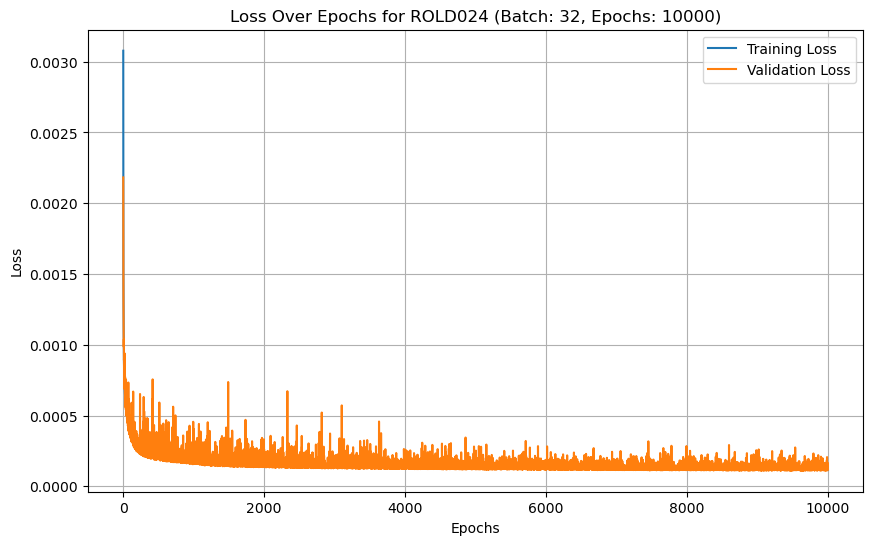


### Training for Location: RSAN018 | Batch Size: 64, Epochs: 10000 ###

Epoch 1/10000
1405/1405 - 2s - loss: 0.0040 - val_loss: 0.0028 - 2s/epoch - 1ms/step
Epoch 2/10000
1405/1405 - 1s - loss: 0.0023 - val_loss: 0.0020 - 1s/epoch - 863us/step
Epoch 3/10000
1405/1405 - 1s - loss: 0.0018 - val_loss: 0.0017 - 1s/epoch - 926us/step
Epoch 4/10000
1405/1405 - 2s - loss: 0.0016 - val_loss: 0.0015 - 2s/epoch - 1ms/step
Epoch 5/10000
1405/1405 - 2s - loss: 0.0014 - val_loss: 0.0013 - 2s/epoch - 1ms/step
Epoch 6/10000
1405/1405 - 1s - loss: 0.0013 - val_loss: 0.0012 - 1s/epoch - 939us/step
Epoch 7/10000
1405/1405 - 1s - loss: 0.0011 - val_loss: 0.0011 - 1s/epoch - 832us/step
Epoch 8/10000
1405/1405 - 1s - loss: 0.0010 - val_loss: 0.0010 - 1s/epoch - 818us/step
Epoch 9/10000
1405/1405 - 1s - loss: 9.6572e-04 - val_loss: 9.2825e-04 - 1s/epoch - 786us/step
Epoch 10/10000
1405/1405 - 1s - loss: 8.9639e-04 - val_loss: 8.4351e-04 - 1s/epoch - 852us/step
Epoch 11/10000
1405/1405 - 1s - loss: 8.3853e-

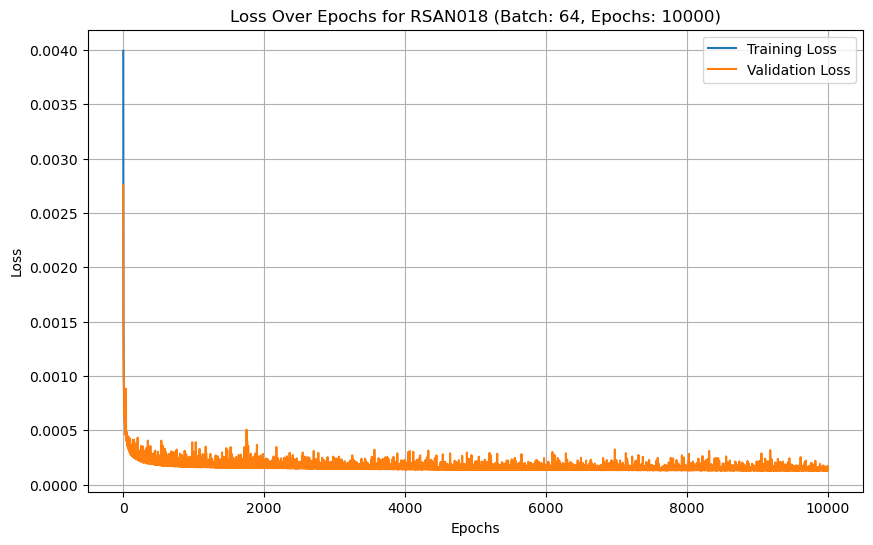


### Training for Location: RSAC092 | Batch Size: 128, Epochs: 8000 ###

Epoch 1/8000
702/702 - 3s - loss: 0.0046 - val_loss: 0.0028 - 3s/epoch - 4ms/step
Epoch 2/8000
702/702 - 2s - loss: 0.0025 - val_loss: 0.0023 - 2s/epoch - 3ms/step
Epoch 3/8000
702/702 - 2s - loss: 0.0021 - val_loss: 0.0020 - 2s/epoch - 3ms/step
Epoch 4/8000
702/702 - 2s - loss: 0.0018 - val_loss: 0.0017 - 2s/epoch - 3ms/step
Epoch 5/8000
702/702 - 2s - loss: 0.0015 - val_loss: 0.0015 - 2s/epoch - 3ms/step
Epoch 6/8000
702/702 - 2s - loss: 0.0014 - val_loss: 0.0013 - 2s/epoch - 3ms/step
Epoch 7/8000
702/702 - 2s - loss: 0.0012 - val_loss: 0.0012 - 2s/epoch - 3ms/step
Epoch 8/8000
702/702 - 2s - loss: 0.0011 - val_loss: 0.0011 - 2s/epoch - 3ms/step
Epoch 9/8000
702/702 - 2s - loss: 0.0011 - val_loss: 0.0010 - 2s/epoch - 3ms/step
Epoch 10/8000
702/702 - 2s - loss: 0.0010 - val_loss: 9.8529e-04 - 2s/epoch - 3ms/step
Epoch 11/8000
702/702 - 2s - loss: 9.6304e-04 - val_loss: 9.5602e-04 - 2s/epoch - 3ms/step
Epoch 12/80

KeyboardInterrupt: 

In [47]:
import numpy as np
import pandas as pd
import keras
import annutilsr
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
np.random.seed(1)  # For reproducibility

calib_prop = 0.8  # 80% of the data for calibration


for location in output_locations:
    output_location = f'{location}_EC'

    if location not in best_configs:
        print(f"Skipping {location} – no config found.")
        continue

    config = best_configs[location]
    batch_size = config['batch_size']
    epochs = config['epochs']

    print(f"\n### Training for Location: {location} | Batch Size: {batch_size}, Epochs: {epochs} ###\n")

    # Prepare datasets
    
    (xallc, yallc), (xallv, yallv), xscaler, yscaler = annutilsr.create_training_sets(
        [dfin_in_base1, dfin_in_base2, dfin_in_base3, dfin_in_base4],
        [dfout_out_base1[[output_location]],
         dfout_out_base2[[output_location]],
         dfout_out_base3[[output_location]],
         dfout_out_base4[[output_location]]],
        calib_slice=slice('1940', '2021'),
        valid_slice=slice('1922', '1939')
    )

    # Calibration/validation masks
    vset = np.random.rand(xallc.shape[0])
    val_mask = (vset >= calib_prop) & (vset < (calib_prop + 0.2))
    train_mask = vset < calib_prop

    xallc_c = xallc[train_mask]
    yallc_c = yallc[train_mask]
    xallc_v = xallc[val_mask]
    yallc_v = yallc[val_mask]

    # Optionally save the datasets
    pd.DataFrame(xallc_c).to_csv(f'{location}_xallc_c.csv', index=False)
    pd.DataFrame(yallc_c).to_csv(f'{location}_yallc_c.csv', index=False)
    pd.DataFrame(xallc_v).to_csv(f'{location}_xallc_v.csv', index=False)
    pd.DataFrame(yallc_v).to_csv(f'{location}_yallc_v.csv', index=False)

    # Build and compile model
    model = build_model(nhidden1=8, nhidden2=2, act_func='sigmoid')
    model.compile(optimizer='adam', loss='mse')

    # Train model
    history = model.fit(
        xallc_c, yallc_c,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(xallc_v, yallc_v),
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=1000, mode="min", restore_best_weights=True)],
        verbose=2
    )

    # Log final losses
    final_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    print(f"Final Training Loss: {final_loss:.6f}, Final Validation Loss: {final_val_loss:.6f}")

    # Save the best model
    annutilsr.save_model(location, model, xscaler, yscaler)

    # Plot training curves
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Over Epochs for {location} (Batch: {batch_size}, Epochs: {epochs})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


In [48]:
# 20240116 HZS
# This code is working properly and exporting the weights and biases in an appropriate format which are used to 
#update the existing weights and biases in the fnet files with the required format.
# We can just run the file from the directory that we save the weights and biases:
#for example: D:/Shared_with_Yiwei/ann_calsim_main

import numpy as np
import pandas as pd
from tensorflow import keras
output_locations = ['CVP_INTAKE', 'MIDR_INTAKE', 'OLDR_CCF', 'ROLD024', 'ROLD034','RSAC081', 'RSAC092', 'RSAC054','RSAN007', 'RSAN018', 'SLMZU011', 'VICT_INTAKE']
#output_locations = ['CVP_INTAKE', 'MIDR_INTAKE', 'OLDR_CCF', 'ROLD024','RSAC081', 'RSAC092', 'RSAC054','RSAN007', 'RSAN018', 'SLMZU011', 'VICT_INTAKE']
#output_locations = ['ROLD024']
#output_locations = ['X2_DIS','CVP_INTAKE', 'MIDR_INTAKE', 'OLDR_CCF', 'ROLD024','RSAC081', 'RSAC092','RSAC054','RSAC054', 
#'RSAN007', 'RSAN018', 'SLMZU003','SLMZU011', 'VICT_INTAKE']
#output_locations = ['RSAC092','RSAN018', 'ROLD024','RSAC081']
#output_locations = ['RSAC092','RSAN018']
#output_locations = ['RSAC092']

for loc in output_locations:
    location = f"{loc}.h5"
    print('Location: ', location)

    annmodel = keras.models.load_model(location)

    for idx, layer in enumerate(annmodel.layers):
        weights = layer.get_weights()
        if len(weights) > 0:
            # Get weights and biases
            layer_weights = weights[0]
            layer_biases = weights[1]

            df_weights = pd.DataFrame(layer_weights)
            df_biases = pd.DataFrame(layer_biases.reshape(-1, 1))  # reshape biases to have a 2D shape

            df_weights_transposed = df_weights.T
            df_biases_transposed = df_biases.T

            df_weights.to_csv(f"{loc}_layer_{idx + 1}_weights.csv", index=False, header=False)
            df_weights_transposed.to_csv(f"{loc}_layer_{idx + 1}_weights_transposed.csv", index=False, header=False)
            
            df_biases.to_csv(f"{loc}_layer_{idx + 1}_biases.csv", index=False, header=False)
            df_biases_transposed.to_csv(f"{loc}_layer_{idx + 1}_biases_transposed.csv", index=False, header=False)


Location:  CVP_INTAKE.h5
Location:  MIDR_INTAKE.h5
Location:  OLDR_CCF.h5
Location:  ROLD024.h5
Location:  ROLD034.h5
Location:  RSAC081.h5
Location:  RSAC092.h5
Location:  RSAC054.h5
Location:  RSAN007.h5
Location:  RSAN018.h5
Location:  SLMZU011.h5
Location:  VICT_INTAKE.h5


Updating weights and bisas for all the stations in the list at once

In [49]:
# Hamed Zamanisabzi 05-10-2024 (all fenet files can be updated automatically at once!)
# This code is working properly and producing the required fnet files with the required format.
# We can just run the file from the directory that we save the weights and biases: for example: D:/Shared_with_Yiwei/ann_calsim_main/Fnet_related
# Defining the function to read and write the Fortran file, and the function to update weights and biases
def read_fortran_file(file_path):
    with open(file_path, 'r') as file:
        return file.readlines()

def write_fortran_file(file_path, content):
    with open(file_path, 'w') as file:
        file.writelines(content)

def update_fortran_weights_biases(fortran_content, start_line, end_line, new_values, prepend='', append=''):
    # Preparing the values string for Fortran format
    formatted_values = ',\n            '.join(new_values)
    
    # Spliting the formatted values into lines
    formatted_value_lines = formatted_values.splitlines(True)

    # Prepending text to the start of the first line if specified
    if prepend and formatted_value_lines:
        formatted_value_lines[0] = prepend + formatted_value_lines[0]

    # Appending '&' to each line except the last line
    for i in range(len(formatted_value_lines) - 1):
        formatted_value_lines[i] = formatted_value_lines[i].rstrip('\n') + ' &\n'

    # Appending '&' to specific end lines if required
    if end_line in [133, 143] and formatted_value_lines:
        formatted_value_lines[-1] = formatted_value_lines[-1].rstrip('\n') + ' &\n'
    elif append and formatted_value_lines:
        formatted_value_lines[-1] = formatted_value_lines[-1].rstrip('\n') + append + '\n'

    # Replacing the content in the Fortran file with the new formatted lines
    fortran_content[start_line:end_line] = formatted_value_lines
    return fortran_content


def load_formatted_values(csv_path):
    df = pd.read_csv(csv_path, header=None)
    formatted_values = df.to_string(header=False, index=False, index_names=False).split('\n')
    return [','.join(ele.split()) for ele in formatted_values]

# Dictionary to hold all file information, including line ranges
files_info = {
    'fnet_Beldan.f90': {
        'weights': {
            'paths': ['./SLMZU011_layer_1_weights.csv', './SLMZU011_layer_2_weights.csv', './SLMZU011_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./SLMZU011_layer_1_biases_transposed.csv', './SLMZU011_layer_2_biases_transposed.csv', './SLMZU011_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },
    'fnet_ORRSL.f90': {
        'weights': {
            'paths': ['./ROLD024_layer_1_weights.csv', './ROLD024_layer_2_weights.csv', './ROLD024_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./ROLD024_layer_1_biases_transposed.csv', './ROLD024_layer_2_biases_transposed.csv', './ROLD024_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },
    'fnet_JP.f90': {
        'weights': {
            'paths': ['./RSAN018_layer_1_weights.csv', './RSAN018_layer_2_weights.csv', './RSAN018_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./RSAN018_layer_1_biases_transposed.csv', './RSAN018_layer_2_biases_transposed.csv', './RSAN018_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },
    'fnet_CO.f90': {
        'weights': {
            'paths': ['./RSAC081_layer_1_weights.csv', './RSAC081_layer_2_weights.csv', './RSAC081_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./RSAC081_layer_1_biases_transposed.csv', './RSAC081_layer_2_biases_transposed.csv', './RSAC081_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },
    'fnet_emm.f90': {
        'weights': {
            'paths': ['./RSAC092_layer_1_weights.csv', './RSAC092_layer_2_weights.csv', './RSAC092_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./RSAC092_layer_1_biases_transposed.csv', './RSAC092_layer_2_biases_transposed.csv', './RSAC092_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },
    'fnet_CVP_intake.f90': {
        'weights': {
            'paths': ['./CVP_INTAKE_layer_1_weights.csv', './CVP_INTAKE_layer_2_weights.csv', './CVP_INTAKE_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./CVP_INTAKE_layer_1_biases_transposed.csv', './CVP_INTAKE_layer_2_biases_transposed.csv', './CVP_INTAKE_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },
    'fnet_MidR_intake.f90': {
        'weights': {
            'paths': ['./MIDR_INTAKE_layer_1_weights.csv', './MIDR_INTAKE_layer_2_weights.csv', './MIDR_INTAKE_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./MIDR_INTAKE_layer_1_biases_transposed.csv', './MIDR_INTAKE_layer_2_biases_transposed.csv', './MIDR_INTAKE_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },
    'fnet_CCFB_intake.f90': {
        'weights': {
            'paths': ['./OLDR_CCF_layer_1_weights.csv', './OLDR_CCF_layer_2_weights.csv', './OLDR_CCF_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./OLDR_CCF_layer_1_biases_transposed.csv', './OLDR_CCF_layer_2_biases_transposed.csv', './OLDR_CCF_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },
    'fnet_antioch.f90': {
        'weights': {
            'paths': ['./RSAN007_layer_1_weights.csv', './RSAN007_layer_2_weights.csv', './RSAN007_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./RSAN007_layer_1_biases_transposed.csv', './RSAN007_layer_2_biases_transposed.csv', './RSAN007_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },
    'fnet_Victoria_intake.f90': {
        'weights': {
            'paths': ['./VICT_INTAKE_layer_1_weights.csv', './VICT_INTAKE_layer_2_weights.csv', './VICT_INTAKE_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./VICT_INTAKE_layer_1_biases_transposed.csv', './VICT_INTAKE_layer_2_biases_transposed.csv', './VICT_INTAKE_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },
    'fnet_LosVaqueros.f90': {
        'weights': {
            'paths': ['./ROLD034_layer_1_weights.csv', './ROLD034_layer_2_weights.csv', './ROLD034_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./ROLD034_layer_1_biases_transposed.csv', './ROLD034_layer_2_biases_transposed.csv', './ROLD034_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },
     'fnet_MTZ.f90': {
        'weights': {
            'paths': ['./RSAC054_layer_1_weights.csv', './RSAC054_layer_2_weights.csv', './RSAC054_layer_3_weights_transposed.csv'],
            'line_ranges': [(7, 133), (135, 143), (145, 146)]
        },
        'biases': {
            'paths': ['./RSAC054_layer_1_biases_transposed.csv', './RSAC054_layer_2_biases_transposed.csv', './RSAC054_layer_3_biases.csv'],
            'line_ranges': [(147, 148), (149, 150), (151, 152)]
        }
    },   
    #ROLD034 - fnet_LosVaqueros.f90-
    #RSAC054 - fnet_MTZ.f90 - 
    
    #'fnet_CVP_intake.f90 = CVP_INTAKE', 'fnet_MidR_intake.f90 = MIDR_INTAKE', 'fnet_CCFB_intake.f90 = OLDR_CCF', 'fnet_antioch.f90 = RSAN007',  'SLMZU003', 'fnet_Victoria_intake.f90 = VICT_INTAKE']
    # more locations can be added here
}

for file_name, paths in files_info.items():
    fortran_file_path = f'./{file_name}'
    fortran_content = read_fortran_file(fortran_file_path)

    # Updating weights
    for weight_info, line_range in zip(paths['weights']['paths'], paths['weights']['line_ranges']):
        formatted_weights = load_formatted_values(weight_info)
        fortran_content = update_fortran_weights_biases(fortran_content, *line_range, formatted_weights, prepend='  Reshape((/', append='/),(/1,2/))')

    # Updating biases
    for bias_info, line_range in zip(paths['biases']['paths'], paths['biases']['line_ranges']):
        formatted_biases = load_formatted_values(bias_info)
        fortran_content = update_fortran_weights_biases(fortran_content, *line_range, formatted_biases, prepend='(/', append='/)')
    

    write_fortran_file(fortran_file_path, fortran_content)


In [50]:
import annutilsr

#output_locations = ['CVP_INTAKE', 'MIDR_INTAKE', 'OLDR_CCF', 'ROLD024','RSAC081', 'RSAC092', 'RSAC054', 'RSAN007', 'RSAN018','SLMZU003', 'SLMZU011', 'VICT_INTAKE','X2_DIS']
#output_locations = ['RSAC092','ROLD024','RSAC081', 'RSAN018']
output_locations = ['CVP_INTAKE', 'MIDR_INTAKE', 'OLDR_CCF', 'ROLD024', 'ROLD034','RSAC081', 'RSAC092', 'RSAC054','RSAN007', 'RSAN018', 'SLMZU011', 'VICT_INTAKE']

# Loop through each location in the output_locations list
for location in output_locations:
    print('Attempting to load model for Location:', location)
    
    try:
        annmodel = annutilsr.load_model(location)
        print(f'Model loaded successfully for {location}')
        if hasattr(annmodel, 'yscaler'):
            print(f"Scale for {location}:", annmodel.xscaler.scale_)
            print(f"Min for {location}:", annmodel.xscaler.min_)
            print(f"Scale for {location}:", annmodel.yscaler.scale_)
            print(f"Min for {location}:", annmodel.yscaler.min_)
        else:
            print(f"The model for {location} does not have a 'yscaler' attribute.")
    except OSError as e:
        print(f'Error loading model for {location}: {e}')

Attempting to load model for Location: CVP_INTAKE
Model loaded successfully for CVP_INTAKE
Scale for CVP_INTAKE: [8.00000000e-01 6.09423673e-05 2.97595274e-06 1.50744066e-05
 1.32676578e-01 1.00783496e-04 8.00000000e-01]
Min for CVP_INTAKE: [ 0.1         0.0474824   0.08642638  0.09568568 -0.31441527  0.58613017
  0.1       ]
Scale for CVP_INTAKE: [0.00071222]
Min for CVP_INTAKE: [0.09350365]
Attempting to load model for Location: MIDR_INTAKE
Model loaded successfully for MIDR_INTAKE
Scale for MIDR_INTAKE: [8.00000000e-01 6.09423673e-05 2.97595274e-06 1.50744066e-05
 1.32676578e-01 1.00783496e-04 8.00000000e-01]
Min for MIDR_INTAKE: [ 0.1         0.0474824   0.08642638  0.09568568 -0.31441527  0.58613017
  0.1       ]
Scale for MIDR_INTAKE: [0.00079476]
Min for MIDR_INTAKE: [0.09070305]
Attempting to load model for Location: OLDR_CCF
Model loaded successfully for OLDR_CCF
Scale for OLDR_CCF: [8.00000000e-01 6.09423673e-05 2.97595274e-06 1.50744066e-05
 1.32676578e-01 1.00783496e-04 8.0

In [15]:
# The following code is working for updating the scale factors of predictors ann.f90 
import annutilsr
#output_locations = ['CVP_INTAKE', 'MIDR_INTAKE', 'OLDR_CCF', 'ROLD024','RSAC081', 'RSAC092', 'RSAC054', 'RSAN007', 'RSAN018','SLMZU003', 'SLMZU011', 'VICT_INTAKE','X2_DIS']
output_locations = ['RSAC092']


fortran_file_path = './ann.f90'

def read_fortran_file(file_path):
    with open(file_path, 'r') as file:
        return file.readlines()

def write_fortran_file(file_path, content):
    with open(file_path, 'w') as file:
        file.writelines(content)

def update_fortran_file(fortran_content, new_values, line_numbers):
    for key, lines in line_numbers.items():
        scale, offset = new_values[key]
        for line_num in lines:
            print(f"Updating {key} at line {line_num + 1}: Scale={scale:.10f}, Offset={offset:.8f}")
            if line_num in [156, 157]:  
                line_format = f"        {key}_scale = {scale:.10f};   {key}_OFFSET = {offset:.8f};\n"
            else:
                line_format = f"    real ::   {key}_scale = {scale:.10f},   {key}_OFFSET = {offset:.8f}\n"
            fortran_content[line_num] = line_format
    return fortran_content

line_numbers = {
    'DXC': [11],  
    'EXP': [12, 156],  
    'SAC': [13, 157],  
    'SJR': [14],  
    'SFtide': [15],  
    'DICU': [16],  
    'VernEC': [17],  
    'emm': [23]  
}

for location in output_locations:
    print(f'Attempting to load model for Location: {location}')
    try:
        annmodel = annutilsr.load_model(location)
        print(f'Model loaded successfully for {location}')
        if hasattr(annmodel, 'yscaler'):
            x_scales = annmodel.xscaler.scale_
            x_mins = annmodel.xscaler.min_
            y_scale = annmodel.yscaler.scale_[0]  
            y_min = annmodel.yscaler.min_[0]      
            keys = ['DXC', 'EXP', 'SAC', 'SJR', 'SFtide', 'DICU', 'VernEC']
            new_values = {key: (x_scales[i], x_mins[i]) for i, key in enumerate(keys)}
            new_values['emm'] = (y_scale, y_min)  
            fortran_content = read_fortran_file(fortran_file_path)
            updated_content = update_fortran_file(fortran_content, new_values, line_numbers)
            write_fortran_file(fortran_file_path, updated_content)
            print("Fortran file updated successfully.")
        else:
            print(f"The model for {location} does not have a 'yscaler' attribute.")
    except OSError as e:
        print(f'Error loading model for {location}: {e}')


Attempting to load model for Location: RSAC092
Model loaded successfully for RSAC092
Updating DXC at line 12: Scale=0.8000000000, Offset=0.10000000
Updating EXP at line 13: Scale=0.0000575311, Offset=0.09520185
Updating EXP at line 157: Scale=0.0000575311, Offset=0.09520185
Updating SAC at line 14: Scale=0.0000029761, Offset=0.08638243
Updating SAC at line 158: Scale=0.0000029761, Offset=0.08638243
Updating SJR at line 15: Scale=0.0000150786, Offset=0.09574525
Updating SFtide at line 16: Scale=0.1326765781, Offset=-0.31441527
Updating DICU at line 17: Scale=0.0001007835, Offset=0.58613017
Updating VernEC at line 18: Scale=0.8000000000, Offset=0.10000000
Updating emm at line 24: Scale=0.0001576848, Offset=0.09974913
Fortran file updated successfully.


Update scale factors in ann.f90 for all the stations

In [51]:
import annutilsr

#output_locations = ['RSAC092', 'RSAN018', 'ROLD024', 'RSAC081']
output_locations = ['CVP_INTAKE', 'MIDR_INTAKE', 'OLDR_CCF', 'ROLD024', 'ROLD034','RSAC081', 'RSAC092', 'RSAC054','RSAN007', 'RSAN018', 'SLMZU011', 'VICT_INTAKE']

fortran_file_path = './ann.f90'

def read_fortran_file(file_path):
    with open(file_path, 'r') as file:
        return file.readlines()

def write_fortran_file(file_path, content):
    with open(file_path, 'w') as file:
        file.writelines(content)

def update_fortran_file(fortran_content, new_values, line_numbers):
    for key, lines in line_numbers.items():
        scale, offset = new_values.get(key, (0.9, 0.1))  
        for line_num in lines:
            print(f"Updating {key} at line {line_num + 1}: Scale={scale:.10f}, Offset={offset:.8f}")
            if line_num in [156, 157]:  
                line_format = f"        {key}_scale = {scale:.10f};   {key}_OFFSET = {offset:.8f};\n"
            else:
                line_format = f"    real ::     {key}_scale = {scale:.10f},   {key}_OFFSET = {offset:.8f}\n"
            fortran_content[line_num] = line_format
    return fortran_content

line_numbers_common = {
    'DXC': [11],  
    'EXP': [12, 156],  
    'SAC': [13, 157],  
    'SJR': [14],  
    'SFtide': [15],  
    'DICU': [16],  
    'VernEC': [17]
}

location_specific_lines = {
    'RSAC092': {'emm': [23]},
    'RSAN018': {'jpt': [21]},
    'ROLD024': {'orrsl': [22]},
    'RSAC081': {'collins': [25]},
    'RSAC054': {'MTZ': [36]},
    'ROLD034': {'losvaqueros': [27]},
    'RSAN007': {'antioch': [24]},
    'SLMZU011': {'beldan': [35]},
    'CVP_INTAKE': {'CVPintake': [33]},
    'MIDR_INTAKE': {'middleriver': [31]},
    'OLDR_CCF': {'ccfb': [29]},
    'VICT_INTAKE': {'VICTintake': [32]}
    
}

for location in output_locations:
    print(f'Attempting to load model for Location: {location}')
    try:
        annmodel = annutilsr.load_model(location)
        print(f'Model loaded successfully for {location}')
        if hasattr(annmodel, 'yscaler'):
            x_scales = annmodel.xscaler.scale_
            x_mins = annmodel.xscaler.min_
            y_scale = annmodel.yscaler.scale_[0]
            y_min = annmodel.yscaler.min_[0]
            keys = ['DXC', 'EXP', 'SAC', 'SJR', 'SFtide', 'DICU', 'VernEC']
            new_values = {key: (x_scales[i], x_mins[i]) for i, key in enumerate(keys)}
            new_values.update({key: (y_scale, y_min) for key in location_specific_lines.get(location, {})})
            combined_line_numbers = {**line_numbers_common, **location_specific_lines.get(location, {})}
            fortran_content = read_fortran_file(fortran_file_path)
            updated_content = update_fortran_file(fortran_content, new_values, combined_line_numbers)
            write_fortran_file(fortran_file_path, updated_content)
            print("Fortran file updated successfully.")
        else:
            print(f"The model for {location} does not have a 'yscaler' attribute.")
    except Exception as e:
        print(f'Error loading or processing model for {location}: {e}')


Attempting to load model for Location: CVP_INTAKE
Model loaded successfully for CVP_INTAKE
Updating DXC at line 12: Scale=0.8000000000, Offset=0.10000000
Updating EXP at line 13: Scale=0.0000609424, Offset=0.04748240
Updating EXP at line 157: Scale=0.0000609424, Offset=0.04748240
Updating SAC at line 14: Scale=0.0000029760, Offset=0.08642638
Updating SAC at line 158: Scale=0.0000029760, Offset=0.08642638
Updating SJR at line 15: Scale=0.0000150744, Offset=0.09568568
Updating SFtide at line 16: Scale=0.1326765781, Offset=-0.31441527
Updating DICU at line 17: Scale=0.0001007835, Offset=0.58613017
Updating VernEC at line 18: Scale=0.8000000000, Offset=0.10000000
Updating CVPintake at line 34: Scale=0.0007122154, Offset=0.09350365
Fortran file updated successfully.
Attempting to load model for Location: MIDR_INTAKE
Model loaded successfully for MIDR_INTAKE
Updating DXC at line 12: Scale=0.8000000000, Offset=0.10000000
Updating EXP at line 13: Scale=0.0000609424, Offset=0.04748240
Updating 

In [52]:
# The following code is working for updating the scale factors of predictors ann.f90 
import annutilsr

output_locations = ['X2_DIS']

fortran_file_path = './ann.f90'

def read_fortran_file(file_path):
    with open(file_path, 'r') as file:
        return file.readlines()

def write_fortran_file(file_path, content):
    with open(file_path, 'w') as file:
        file.writelines(content)

def update_fortran_file(fortran_content, new_values, line_numbers):
    for key, lines in line_numbers.items():
        scale, offset = new_values[key]
        for line_num in lines:
            print(f"Updating {key} at line {line_num + 1}: Scale={scale:.10f}, Offset={offset:.8f}")
            if line_num == 322:  
                line_format = f"        {key}_scale = {scale:.10f};   {key}_OFFSET = {offset:.8f};\n"
            else:
                line_format = f"    real :: {key}_scale = {scale:.10f},   {key}_OFFSET = {offset:.8f}\n"
            fortran_content[line_num] = line_format
    return fortran_content

line_numbers = {
    'EXP': [322],
    'x2': [34],

}

for location in output_locations:
    print(f'Attempting to load model for Location: {location}')
    try:
        annmodel = annutilsr.load_model(location)
        print(f'Model loaded successfully for {location}')
        if hasattr(annmodel, 'yscaler'):
            x_scales = annmodel.xscaler.scale_
            x_mins = annmodel.xscaler.min_
            y_scale = annmodel.yscaler.scale_[0]  
            y_min = annmodel.yscaler.min_[0]      
            keys = ['EXP', 'smscg', 'tide']
            new_values = {key: (x_scales[i], x_mins[i]) for i, key in enumerate(keys)}
            new_values['x2'] = (y_scale, y_min)  
            fortran_content = read_fortran_file(fortran_file_path)
            updated_content = update_fortran_file(fortran_content, new_values, line_numbers)
            write_fortran_file(fortran_file_path, updated_content)
            print("Fortran file updated successfully.")
        else:
            print(f"The model for {location} does not have a 'yscaler' attribute.")
    except OSError as e:
        print(f'Error loading model for {location}: {e}')


Attempting to load model for Location: X2_DIS
Model loaded successfully for X2_DIS
Updating EXP at line 323: Scale=0.0000025351, Offset=0.09302449
Updating x2 at line 35: Scale=0.0159534454, Offset=-0.65132659
Fortran file updated successfully.


In [35]:
#location = 'RSAC081'
location = 'X2_DIS'
import annutilsr
output_location = '%s_EC' % location
print('Location: ', location)
annmodel = annutilsr.load_model(location)


Location:  X2_DIS


In [37]:
annmodel.xscaler.data_min_, annmodel.xscaler.data_max_

(array([2403.23595794,    0.        ,    3.12349987]),
 array([3.39934502e+05, 1.00000000e+00, 9.15320015e+00]))

In [14]:
annmodel.yscaler.data_min_, annmodel.yscaler.data_max_

(array([0.]), array([14846.18652344]))

In [39]:
annmodel.xscaler.feature_range

(0.1, 0.9)

In [40]:
annmodel.xscaler.min_, annmodel.xscaler.scale_

(array([ 0.09430397,  0.1       , -0.31441527]),
 array([2.37015080e-06, 8.00000000e-01, 1.32676578e-01]))

In [38]:
annmodel.yscaler.min_, annmodel.yscaler.scale_

(array([-0.57331889]), array([0.01519148]))

training X2 estimation process

In [25]:
dfin_in_x2_base1 = pd.read_csv(os.path.join(path_data, '.\dcr_base_1_x2_input.csv'), index_col=0, parse_dates=True)
dfin_in_x2_base2 = pd.read_csv(os.path.join(path_data, '.\dcr_base_2_x2_input.csv'), index_col=0, parse_dates=True)
dfin_in_x2_base3 = pd.read_csv(os.path.join(path_data, '.\dcr_base_3_x2_input.csv'), index_col=0, parse_dates=True)
dfin_in_x2_base4 = pd.read_csv(os.path.join(path_data, '.\dcr_base_4_x2_input.csv'), index_col=0, parse_dates=True)

dfout_out_x2_base1 = pd.read_csv(os.path.join(path_data, '.\dcr_base_1_x2_output.csv'), index_col=0, parse_dates=True)
dfout_out_x2_base2 = pd.read_csv(os.path.join(path_data, '.\dcr_base_2_x2_output.csv'), index_col=0, parse_dates=True)
dfout_out_x2_base3 = pd.read_csv(os.path.join(path_data, '.\dcr_base_3_x2_output.csv'), index_col=0, parse_dates=True)
dfout_out_x2_base4 = pd.read_csv(os.path.join(path_data, '.\dcr_base_4_x2_output.csv'), index_col=0, parse_dates=True)

In [26]:
output_locations = ['X2_DIS']
calib_slice = slice('1940', '2021')
valid_slice = slice('1923', '1939')

In [27]:
# Define Sequential model with 3 layers
NFEATURES = 54  # (8 + 10)*3


def build_model(nhidden1=8, nhidden2=2, act_func='sigmoid'):
    model = keras.Sequential(
        [
            layers.Input(shape=(NFEATURES)),
            layers.Dense(nhidden1, activation=act_func),
            layers.Dense(nhidden2, activation=act_func),
            layers.Dense(1, activation=keras.activations.linear)
        ])
    model.compile(optimizer=keras.optimizers.Adam(
        learning_rate=0.001), loss="mse")
    #model.compile(optimizer=keras.optimizers.RMSprop(), loss="mse")
    return model

Dimensions of xallc: (112132, 54)
Dimensions of xallc_c: (89667, 54)
Dimensions of yallc_c: (89667, 1)
Dimensions of xallc_v: (22465, 54)
Dimensions of yallc_v: (22465, 1)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 440       
                                                                 
 dense_1 (Dense)             (None, 2)                 18        
                                                                 
 dense_2 (Dense)             (None, 1)                 3         
                                                                 
Total params: 461
Trainable params: 461
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10000
701/701 [==============================] - 1s 1ms/step - loss: 0.1858 - val_loss: 0.0440
Epoch 2/10000
701/701 [========================

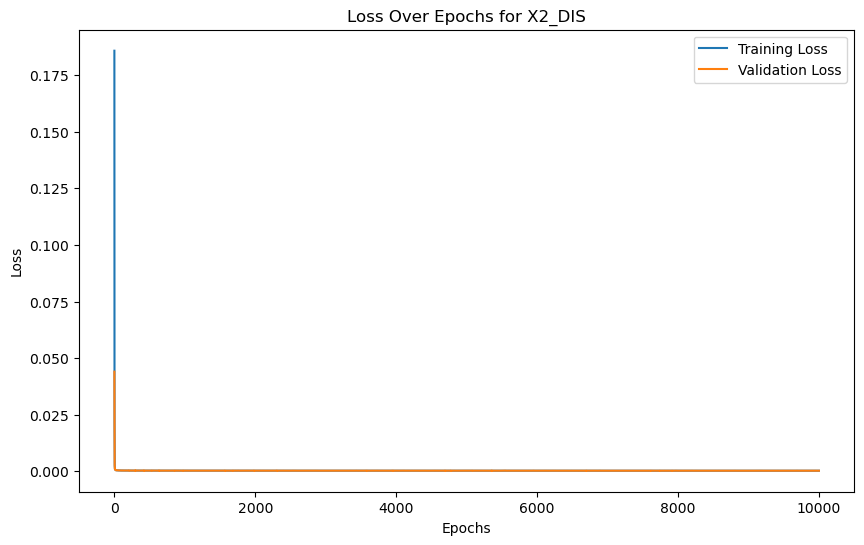

In [28]:
import numpy as np
import pandas as pd
import keras
import annutilsr
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

np.random.seed(1)  # For reproducibility

calib_prop = 0.8  # 80% of the data for calibration

for location in output_locations:
    output_location = f'{location}'

    (xallc, yallc), (xallv, yallv), xscaler, yscaler = annutilsr.create_training_sets(
                                      [dfin_in_x2_base1, dfin_in_x2_base2 , dfin_in_x2_base3 , dfin_in_x2_base4],
                                      [dfout_out_x2_base1[[output_location]],
                                       dfout_out_x2_base2[[output_location]],
                                       dfout_out_x2_base3[[output_location]],
                                       dfout_out_x2_base4[[output_location]]],
                                      calib_slice=slice('1940', '2021'),
                                      valid_slice=slice('1922', '1939'))

    print("Dimensions of xallc:", xallc.shape)
    
    vset = np.random.rand(xallc.shape[0])
    val_mask = (vset >= calib_prop) & (vset < (calib_prop + 0.2))
    train_mask = vset < calib_prop

    xallc_c = xallc[train_mask]
    yallc_c = yallc[train_mask]
    xallc_v = xallc[val_mask]
    yallc_v = yallc[val_mask]


    print("Dimensions of xallc_c:", xallc_c.shape)
    print("Dimensions of yallc_c:", yallc_c.shape)
    print("Dimensions of xallc_v:", xallc_v.shape)
    print("Dimensions of yallc_v:", yallc_v.shape)

    model = build_model(nhidden1=8, nhidden2=2, act_func='sigmoid')
    model.compile(optimizer='adam', loss='mse')
    model.summary()

    history = model.fit(
        xallc_c,
        yallc_c,
        #epochs=20000,
        epochs=10000,
        #epochs=10,
        batch_size=128,
        validation_data=(xallc_v, yallc_v),
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=1000, mode="min", restore_best_weights=True)]
    )
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Over Epochs for {location}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    
    annutilsr.save_model(location, model, xscaler, yscaler)


In [53]:
# 20240116 HZS
# This code is working properly and exporting the weights and biases in an appropriate format which are used to 
#update the existing weights and biases in the fnet files with the required format.
# We can just run the file from the directory that we save the weights and biases:
#for example: D:/Shared_with_Yiwei/ann_calsim_main

import numpy as np
import pandas as pd
from tensorflow import keras

output_locations = ['X2_DIS']


for loc in output_locations:
    location = f"{loc}.h5"
    print('Location: ', location)

    annmodel = keras.models.load_model(location)

    for idx, layer in enumerate(annmodel.layers):
        weights = layer.get_weights()
        if len(weights) > 0:
            # Get weights and biases
            layer_weights = weights[0]
            layer_biases = weights[1]

            df_weights = pd.DataFrame(layer_weights)
            df_biases = pd.DataFrame(layer_biases.reshape(-1, 1))  # reshape biases to have a 2D shape

            df_weights_transposed = df_weights.T
            df_biases_transposed = df_biases.T

            df_weights.to_csv(f"{loc}_layer_{idx + 1}_weights.csv", index=False, header=False)
            df_weights_transposed.to_csv(f"{loc}_layer_{idx + 1}_weights_transposed.csv", index=False, header=False)
            
            df_biases.to_csv(f"{loc}_layer_{idx + 1}_biases.csv", index=False, header=False)
            df_biases_transposed.to_csv(f"{loc}_layer_{idx + 1}_biases_transposed.csv", index=False, header=False)


Location:  X2_DIS.h5


In [54]:
# Hamed Zamanisabzi 05-10-2024 (fnet_X2.f90   (X2_DIS))
# This code is working properly and producing the required fnet files with the required format.
# We can just run the file from the directory that we save the weights and biases: for example: D:/Shared_with_Yiwei/ann_calsim_main/Fnet_related
import pandas as pd

# Defining the function to read and write the Fortran file, and the function to update weights and biases
def read_fortran_file(file_path):
    with open(file_path, 'r') as file:
        return file.readlines()

def write_fortran_file(file_path, content):
    with open(file_path, 'w') as file:
        file.writelines(content)

def update_fortran_weights_biases(fortran_content, start_line, end_line, new_values, prepend='', append=''):
    # Prepare the values string for Fortran format
    formatted_values = ',\n            '.join(new_values)
    
    # Split the formatted values into lines
    formatted_value_lines = formatted_values.splitlines(True)

    # Move commas to the beginning of each line (except the first line)
    # and prepend three tabs before the comma
    for i in range(1, len(formatted_value_lines)):
        formatted_value_lines[i] = formatted_value_lines[i].lstrip()  # Remove leading spaces
        if formatted_value_lines[i]:
            formatted_value_lines[i] = '\t\t\t,' + formatted_value_lines[i]

    # Prepend text to the start of the first line if specified
    if prepend and formatted_value_lines:
        formatted_value_lines[0] = prepend + formatted_value_lines[0]

    # Append '&' to each line except the last line, and remove any trailing commas
    for i in range(len(formatted_value_lines) - 1):
        formatted_value_lines[i] = formatted_value_lines[i].rstrip(',\n') + ' &\n'

    # Append text to specific end lines if required
    if end_line in [61, 71] and formatted_value_lines:
        formatted_value_lines[-1] = formatted_value_lines[-1].rstrip(',\n') + ' &\n'
    elif append and formatted_value_lines:
        formatted_value_lines[-1] = formatted_value_lines[-1].rstrip(',\n') + append + '\n'

    # Replace the content in the Fortran file with the new formatted lines
    fortran_content[start_line:end_line] = formatted_value_lines
    return fortran_content

# File paths
# Relative File paths
fortran_file_path = './fnet_X2.f90'
weights_csv_path_layer_one = './X2_DIS_layer_1_weights.csv'
weights_csv_path_layer_two = './X2_DIS_layer_2_weights.csv'
biases_csv_path_layer_one = './X2_DIS_layer_1_biases_transposed.csv'
biases_csv_path_layer_two = './X2_DIS_layer_2_biases_transposed.csv'
biases_csv_path_layer_three = './X2_DIS_layer_3_biases.csv'
weights_csv_path_layer_three = './X2_DIS_dis_layer_3_weights_transposed.csv'


# Loading the weights for Layer 1 from the CSV file
weights_df_layer_one = pd.read_csv(weights_csv_path_layer_one, header=None)
formatted_weights_layer_one = weights_df_layer_one.to_string(header=False, index=False, index_names=False).split('\n')
formatted_weights_layer_one = [','.join(ele.split()) for ele in formatted_weights_layer_one]

# Loading the weights for Layer 2 from the CSV file
weights_df_layer_two = pd.read_csv(weights_csv_path_layer_two, header=None)
formatted_weights_layer_two = weights_df_layer_two.to_string(header=False, index=False, index_names=False).split('\n')
formatted_weights_layer_two = [','.join(ele.split()) for ele in formatted_weights_layer_two]

# Loading the biases for Layer 1 from the CSV file
biases_df_layer_one = pd.read_csv(biases_csv_path_layer_one, header=None)
formatted_biases_layer_one = biases_df_layer_one.to_string(header=False, index=False, index_names=False).split('\n')
formatted_biases_layer_one = [','.join(ele.split()) for ele in formatted_biases_layer_one]

# Loading the biases for Layer 2 from the CSV file
biases_csv_path_layer_two = './X2_DIS_layer_2_biases_transposed.csv'
biases_df_layer_two = pd.read_csv(biases_csv_path_layer_two, header=None)
formatted_biases_layer_two = biases_df_layer_two.to_string(header=False, index=False, index_names=False).split('\n')
formatted_biases_layer_two = [','.join(ele.split()) for ele in formatted_biases_layer_two]

# Loading the biases for Layer 3 from the CSV file
biases_csv_path_layer_three = './X2_DIS_layer_3_biases.csv'
biases_df_layer_three = pd.read_csv(biases_csv_path_layer_three, header=None)
formatted_biases_layer_three = biases_df_layer_three.to_string(header=False, index=False, index_names=False).split('\n')
formatted_biases_layer_three = [','.join(ele.split()) for ele in formatted_biases_layer_three]



# Loading the weights for Layer 3 from the CSV file
weights_csv_path_layer_three = './X2_DIS_layer_3_weights_transposed.csv'
weights_df_layer_three = pd.read_csv(weights_csv_path_layer_three, header=None)
formatted_weights_layer_three = weights_df_layer_three.to_string(header=False, index=False, index_names=False).split('\n')
formatted_weights_layer_three = [','.join(ele.split()) for ele in formatted_weights_layer_three]


fortran_content = read_fortran_file(fortran_file_path)

# Updating the Fortran file with new weights for Layer 1 (Lines 9 to 134)
fortran_content = update_fortran_weights_biases(fortran_content, 7, 61, formatted_weights_layer_one, prepend='  Reshape((/')

# Updating the Fortran file with new weights for Layer 2 (Lines 136 to 143)
fortran_content = update_fortran_weights_biases(fortran_content, 63, 71, formatted_weights_layer_two, prepend='  Reshape((/')

# Updating the Fortran file with new biases for Layer 1 (Line 148)
fortran_content = update_fortran_weights_biases(fortran_content, 75, 76, formatted_biases_layer_one, prepend='(/', append='/)')

# Updating the Fortran file with new biases for Layer 2 (Line 150)
# Adjust the line numbers as per zero-based indexing
fortran_content = update_fortran_weights_biases(fortran_content, 77, 78, formatted_biases_layer_two, prepend='(/', append='/)')

# Updating the Fortran file with new biases for Layer 3 (Line 152)
# Adjust the line numbers as per zero-based indexing
fortran_content = update_fortran_weights_biases(fortran_content, 79, 80, formatted_biases_layer_three, prepend='(/', append='/)')

# Updating the Fortran file with new weights for Layer 3 (Line 146)
# Adjusting the line numbers as per zero-based indexing
fortran_content = update_fortran_weights_biases(fortran_content, 73, 74, formatted_weights_layer_three, prepend='  Reshape((/', append='/),(/1,2/))')

# Writing the updated content back to the Fortran file
write_fortran_file(fortran_file_path, fortran_content)

In [55]:
# The following code is working for updating the scale factors of predictors ann.f90 
import annutilsr

output_locations = ['X2_DIS']

fortran_file_path = './ann.f90'

def read_fortran_file(file_path):
    with open(file_path, 'r') as file:
        return file.readlines()

def write_fortran_file(file_path, content):
    with open(file_path, 'w') as file:
        file.writelines(content)

def update_fortran_file(fortran_content, new_values, line_numbers):
    for key, lines in line_numbers.items():
        scale, offset = new_values[key]
        for line_num in lines:
            print(f"Updating {key} at line {line_num + 1}: Scale={scale:.10f}, Offset={offset:.8f}")
            if line_num == 322:  
                line_format = f"        {key}_scale = {scale:.10f};   {key}_OFFSET = {offset:.8f};\n"
            else:
                line_format = f"    real :: {key}_scale = {scale:.10f},   {key}_OFFSET = {offset:.8f}\n"
            fortran_content[line_num] = line_format
    return fortran_content

line_numbers = {
    'EXP': [322],
    'x2': [34],

}

for location in output_locations:
    print(f'Attempting to load model for Location: {location}')
    try:
        annmodel = annutilsr.load_model(location)
        print(f'Model loaded successfully for {location}')
        if hasattr(annmodel, 'yscaler'):
            x_scales = annmodel.xscaler.scale_
            x_mins = annmodel.xscaler.min_
            y_scale = annmodel.yscaler.scale_[0]  
            y_min = annmodel.yscaler.min_[0]      
            keys = ['EXP', 'smscg', 'tide']
            new_values = {key: (x_scales[i], x_mins[i]) for i, key in enumerate(keys)}
            new_values['x2'] = (y_scale, y_min)  
            fortran_content = read_fortran_file(fortran_file_path)
            updated_content = update_fortran_file(fortran_content, new_values, line_numbers)
            write_fortran_file(fortran_file_path, updated_content)
            print("Fortran file updated successfully.")
        else:
            print(f"The model for {location} does not have a 'yscaler' attribute.")
    except OSError as e:
        print(f'Error loading model for {location}: {e}')


Attempting to load model for Location: X2_DIS
Model loaded successfully for X2_DIS
Updating EXP at line 323: Scale=0.0000025351, Offset=0.09302449
Updating x2 at line 35: Scale=0.0159534454, Offset=-0.65132659
Fortran file updated successfully.


# Model Evaluation: Training Statistics, Plots & PDF Report

This section loads all trained ANN models, generates predictions on calibration (1940–2021) and testing (1922–1939) periods, computes performance statistics at **daily** and **monthly** scales, and exports:
- **CSV file** with all statistics (`training_statistics_summary.csv`)
- **PDF report** (`ANN_Training_Summary_Report.pdf`) with time series plots, scatter plots, and summary tables for all stations
## EC Standalone Prediction — All Stations (Base 1-4)
Specifically, load each trained EC model, create scaled antecedent datasets from (for example, `dcr_base_1_input.csv` / `dcr_base_1_output.csv`), predict, inverse-scale, compare to DSM2, compute statistics, and generate PDF reports.

In [102]:
# =====================================================================
# EC Standalone Prediction — Selected Stations × 4 Base Cases
# =====================================================================
import numpy as np
import pandas as pd
import os
import annutilsr
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

path_data  = r'C:\Users\hzamanis\Documents\Projects\ann_calsim'
output_dir = r'C:\Users\hzamanis\Documents\Projects\ann_calsim'

train_slice = slice('1940', '2021')
test_slice  = slice('1922', '1939')

# Selected EC stations
ec_station_list = [
    'RSAC092', 'RSAC054', 'ROLD024', 'RSAC081', 'RSAN018',
]

# 4 base cases — input/output file pairs
base_cases = [
    ('Base_1', 'dcr_base_1_input.csv', 'dcr_base_1_output.csv'),
    ('Base_2', 'dcr_base_2_input.csv', 'dcr_base_2_output.csv'),
    ('Base_3', 'dcr_base_3_input.csv', 'dcr_base_3_output.csv'),
    ('Base_4', 'dcr_base_4_input.csv', 'dcr_base_4_output.csv'),
]

def _stats(actual, predicted):
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a, p = actual[mask], predicted[mask]
    if len(a) < 2:
        return {}
    slope = np.sum(a * p) / np.sum(a**2) if np.sum(a**2) != 0 else 1.0
    ss_res = np.sum((p - slope * a)**2)
    ss_tot = np.sum(p**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0.0
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    nse  = 1 - np.sum((a - p)**2) / np.sum((a - np.mean(a))**2)
    pbias = 100.0 * np.sum(p - a) / np.sum(a) if np.sum(a) != 0 else np.nan
    obs_range = a.max() - a.min()
    nrmse = (rmse / obs_range * 100) if obs_range != 0 else np.nan
    return {'R²': round(r2, 4), 'Slope': round(slope, 6), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'NSE': round(nse, 4), 'PBIAS': round(pbias, 4), 'N': int(len(a)),
            'NRMSE': round(nrmse, 2)}

# =====================================================================
# Master dict:  ec_results[base_label][station] = { daily/monthly data + stats }
# =====================================================================
ec_results = {}

for base_label, in_file, out_file in base_cases:
    print(f"\n{'#'*70}")
    print(f"  {base_label}:  {in_file}  /  {out_file}")
    print(f"{'#'*70}")

    ec_dfin_raw  = pd.read_csv(os.path.join(path_data, in_file),
                               index_col=0, parse_dates=True)
    ec_dfout_raw = pd.read_csv(os.path.join(path_data, out_file),
                               index_col=0, parse_dates=True)

    print(f"  Input shape:  {ec_dfin_raw.shape}   Output shape: {ec_dfout_raw.shape}")

    ec_results[base_label] = {}

    for station in ec_station_list:
        print(f"\n  {'='*55}")
        print(f"    {base_label} — {station}")
        print(f"  {'='*55}")

        output_col = f'{station}_EC'
        if output_col not in ec_dfout_raw.columns:
            print(f"    ⚠ Column '{output_col}' not found — skipping.")
            continue

        # --- Load trained model & scalers ---
        try:
            model = annutilsr.load_model(station)
        except Exception as e:
            print(f"    ⚠ Could not load model for {station}: {e} — skipping.")
            continue

        xs = model.xscaler
        ys = model.yscaler

        # --- Synchronize ---
        dfout_single = ec_dfout_raw[[output_col]].copy()
        dfin_sync, dfout_sync = annutilsr.synchronize(ec_dfin_raw, dfout_single)

        # --- Scale ---
        dfin_scaled = pd.DataFrame(
            xs.transform(dfin_sync), index=dfin_sync.index, columns=dfin_sync.columns)
        dfout_scaled = pd.DataFrame(
            ys.transform(dfout_sync), index=dfout_sync.index, columns=dfout_sync.columns)

        # --- Antecedent inputs ---
        dfx_ant = annutilsr.create_antecedent_inputs(dfin_scaled)
        dfy_ali = annutilsr.trim_output_to_index(dfout_scaled, dfx_ant.index)

        print(f"    Antecedent: {dfx_ant.shape},  Aligned output: {dfy_ali.shape}")

        # --- Export scaled antecedent for first station / Base_1 for inspection ---
        if base_label == 'Base_1' and station == ec_station_list[0]:
            ec_ant_csv = os.path.join(output_dir,
                f'EC_{station}_Base_1_scaled_antecedent_inputs.csv')
            dfx_ant.to_csv(ec_ant_csv)
            print(f"    ➤ Scaled antecedent exported ({dfx_ant.shape[1]} cols): {ec_ant_csv}")
            print(f"      Column order: {list(dfx_ant.columns)}")

        # --- Split train / test ---
        x_tr = dfx_ant.loc[train_slice];  y_tr = dfy_ali.loc[train_slice]
        x_te = dfx_ant.loc[test_slice];   y_te = dfy_ali.loc[test_slice]

        # --- Predict ---
        yp_tr_scaled = model.model.predict(x_tr.values, verbose=0)
        yp_te_scaled = model.model.predict(x_te.values, verbose=0)

        # --- Inverse-scale ---
        yp_tr = pd.DataFrame(ys.inverse_transform(yp_tr_scaled),
                             index=x_tr.index, columns=[f'{station}_ANN'])
        yp_te = pd.DataFrame(ys.inverse_transform(yp_te_scaled),
                             index=x_te.index, columns=[f'{station}_ANN'])
        ya_tr = pd.DataFrame(ys.inverse_transform(y_tr.values),
                             index=y_tr.index, columns=[f'{station}_DSM2'])
        ya_te = pd.DataFrame(ys.inverse_transform(y_te.values),
                             index=y_te.index, columns=[f'{station}_DSM2'])

        # --- Combine daily & monthly ---
        d_tr = pd.concat([ya_tr, yp_tr], axis=1)
        d_te = pd.concat([ya_te, yp_te], axis=1)
        m_tr = d_tr.resample('ME').mean().dropna()
        m_te = d_te.resample('ME').mean().dropna()

        # --- Save CSVs ---
        d_tr.to_csv(os.path.join(output_dir, f'{station}_{base_label}_daily_train_comparison.csv'))
        d_te.to_csv(os.path.join(output_dir, f'{station}_{base_label}_daily_test_comparison.csv'))
        m_tr.to_csv(os.path.join(output_dir, f'{station}_{base_label}_monthly_train_comparison.csv'))
        m_te.to_csv(os.path.join(output_dir, f'{station}_{base_label}_monthly_test_comparison.csv'))

        # --- Stats ---
        dsm2_col = f'{station}_DSM2'
        ann_col  = f'{station}_ANN'
        st_d_tr = _stats(d_tr[dsm2_col].values, d_tr[ann_col].values)
        st_d_te = _stats(d_te[dsm2_col].values, d_te[ann_col].values)
        st_m_tr = _stats(m_tr[dsm2_col].values, m_tr[ann_col].values)
        st_m_te = _stats(m_te[dsm2_col].values, m_te[ann_col].values)

        print(f"    Daily  Train R²={st_d_tr.get('R²','N/A')}  RMSE={st_d_tr.get('RMSE','N/A')}  NSE={st_d_tr.get('NSE','N/A')}")
        print(f"    Daily  Test  R²={st_d_te.get('R²','N/A')}  RMSE={st_d_te.get('RMSE','N/A')}  NSE={st_d_te.get('NSE','N/A')}")
        print(f"    Monthly Train R²={st_m_tr.get('R²','N/A')}  RMSE={st_m_tr.get('RMSE','N/A')}  NSE={st_m_tr.get('NSE','N/A')}")
        print(f"    Monthly Test  R²={st_m_te.get('R²','N/A')}  RMSE={st_m_te.get('RMSE','N/A')}  NSE={st_m_te.get('NSE','N/A')}")

        ec_results[base_label][station] = {
            'daily_train': d_tr, 'daily_test': d_te,
            'monthly_train': m_tr, 'monthly_test': m_te,
            'dsm2_col': dsm2_col, 'ann_col': ann_col,
            'stats_daily_train': st_d_tr, 'stats_daily_test': st_d_te,
            'stats_monthly_train': st_m_tr, 'stats_monthly_test': st_m_te,
            'xscaler': xs, 'yscaler': ys,
        }

# --- Combined stats CSV (all cases × all stations) ---
all_ec_stats = []
for base_label in ec_results:
    for station, r in ec_results[base_label].items():
        for period, scale, key in [
            ('Training (1940-2021)', 'Daily',   'stats_daily_train'),
            ('Training (1940-2021)', 'Monthly', 'stats_monthly_train'),
            ('Testing (1922-1939)',  'Daily',   'stats_daily_test'),
            ('Testing (1922-1939)',  'Monthly', 'stats_monthly_test'),
        ]:
            s = r[key]
            if s:
                all_ec_stats.append({'Base': base_label, 'Station': station,
                                     'Period': period, 'Scale': scale, **s})

ec_stats_df = pd.DataFrame(all_ec_stats)
ec_stats_df.to_csv(os.path.join(output_dir, 'EC_all_stations_all_cases_prediction_statistics.csv'), index=False)
print(f"\n{'='*70}")
print(f"EC prediction complete: {len(ec_results)} cases × {len(ec_station_list)} stations.")
print(f"Statistics saved to: EC_all_stations_all_cases_prediction_statistics.csv")
print(f"{'='*70}")


######################################################################
  Base_1:  dcr_base_1_input.csv  /  dcr_base_1_output.csv
######################################################################
  Input shape:  (34940, 7)   Output shape: (36765, 12)

    Base_1 — RSAC092
    Antecedent: (34582, 126),  Aligned output: (34582, 1)
    ➤ Scaled antecedent exported (126 cols): C:\Users\hzamanis\Documents\Projects\ann_calsim\EC_RSAC092_Base_1_scaled_antecedent_inputs.csv
      Column order: ['dcc_D0', 'dcc_D1', 'dcc_D2', 'dcc_D3', 'dcc_D4', 'dcc_D5', 'dcc_D6', 'dcc_D7', 'dcc_MA0', 'dcc_MA1', 'dcc_MA2', 'dcc_MA3', 'dcc_MA4', 'dcc_MA5', 'dcc_MA6', 'dcc_MA7', 'dcc_MA8', 'dcc_MA9', 'exports_D0', 'exports_D1', 'exports_D2', 'exports_D3', 'exports_D4', 'exports_D5', 'exports_D6', 'exports_D7', 'exports_MA0', 'exports_MA1', 'exports_MA2', 'exports_MA3', 'exports_MA4', 'exports_MA5', 'exports_MA6', 'exports_MA7', 'exports_MA8', 'exports_MA9', 'sac_D0', 'sac_D1', 'sac_D2', 'sac_D3', 'sac_D4', '

In [103]:
# =====================================================================
# EC — Generate TWO PDF Reports PER BASE CASE (4 cases × 2 reports = 8 PDFs)
#   Report 1: Full (Daily + Monthly) — per-station pages
#   Report 2: Monthly-only — per-station pages
# =====================================================================
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np, os

TABLE_FONTSIZE = 8
UNIT_LABEL = 'EC (µS/cm)'
UNIT_SHORT = 'µS/cm'

def calc_nrmse(actual, predicted):
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    obs_range = actual.max() - actual.min()
    return (rmse / obs_range * 100) if obs_range != 0 else np.nan

# =====================================================================
# Helper functions — all accept `res` (the per-station results dict)
# and `base_label` for titles
# =====================================================================

def ec_cover_page(pdf, station, base_label, res, subtitle_extra=''):
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
    ax.axhspan(0.62, 0.88, color='#4a86c8', zorder=0)
    ax.text(0.50, 0.82, 'ANN Surrogate Model — System Summary Report',
            fontsize=22, fontweight='bold', color='white',
            ha='center', va='center', transform=ax.transAxes)
    ax.text(0.50, 0.74,
            f'{station} EC — {base_label} Standalone Evaluation{subtitle_extra}',
            fontsize=16, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    ax.text(0.50, 0.67, 'Delta Channel Reconfiguration (DCR) Study',
            fontsize=14, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    meta = [
        ('Model',           f'{station}  (TensorFlow / Keras .h5)'),
        ('Architecture',    'Input → Dense(8, sigmoid) → Dense(2, sigmoid) → Dense(1, linear)'),
        ('Predictors',      'dcc, exports, sac, sjr, tide, net_dcd, smscg  (7 × 18 = 126 features)'),
        ('Training Period', '1940 – 2021  (Calibration)'),
        ('Testing Period',  '1922 – 1939  (Independent Validation)'),
        ('Scaling',         f'MinMaxScaler  range {res["xscaler"].feature_range}'),
        ('Report Generated', datetime.now().strftime('%B %d, %Y  %H:%M')),
    ]
    y_pos = 0.52
    for label, value in meta:
        ax.text(0.18, y_pos, f'{label}:', fontsize=11, fontweight='bold',
                color='#1f4e79', ha='left', va='center', transform=ax.transAxes)
        ax.text(0.42, y_pos, value, fontsize=11, color='#333333',
                ha='left', va='center', transform=ax.transAxes)
        y_pos -= 0.05
    ax.text(0.50, 0.08,
            'California Department of Water Resources — Bay-Delta Office',
            fontsize=10, color='#777777', ha='center', va='center',
            transform=ax.transAxes, style='italic')
    pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_stats_page(pdf, station, rows_data, title_suffix=''):
    col_headers = ['Period', 'Scale', 'R²', 'RMSE', 'NRMSE (%)', 'MAE', 'NSE', 'PBIAS (%)', 'N']
    table_data = []
    for period_lbl, scale_lbl, st in rows_data:
        table_data.append([period_lbl, scale_lbl,
            f"{st['R²']:.4f}", f"{st['RMSE']:.4f}", f"{st.get('NRMSE', 0):.2f}",
            f"{st['MAE']:.4f}", f"{st['NSE']:.4f}", f"{st['PBIAS']:.4f}", str(st['N'])])
    fig, ax = plt.subplots(figsize=(11, 8.5)); ax.axis('off')
    ax.set_title(f'{station} — Performance Statistics{title_suffix}',
                 fontsize=14, fontweight='bold', color='#1f4e79', pad=20)
    table = ax.table(cellText=table_data, colLabels=col_headers,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(TABLE_FONTSIZE)
    table.auto_set_column_width(col=list(range(len(col_headers))))
    table.scale(1.2, 2.2)
    for j in range(len(col_headers)):
        cell = table[0, j]
        cell.set_facecolor('#1f4e79')
        cell.set_text_props(color='white', fontweight='bold')
    for i in range(len(table_data)):
        c = '#dce6f1' if 'Training' in table_data[i][0] else '#fde9d9'
        for j in range(len(col_headers)):
            table[i + 1, j].set_facecolor(c)
    iy = 0.18
    ax.text(0.05, iy, 'Interpretation Guide:', fontsize=10, fontweight='bold',
            color='#1f4e79', transform=ax.transAxes)
    ax.text(0.05, iy - 0.04,
            '• R² > 0.90 and NSE > 0.90 indicate excellent model performance.\n'
            '• PBIAS close to 0% indicates minimal systematic bias.\n'
            f'• RMSE and MAE are in the original units ({UNIT_SHORT}).',
            fontsize=9, color='#333333', transform=ax.transAxes,
            verticalalignment='top', linespacing=1.5)
    plt.tight_layout(); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_monthly_plots_page(pdf, station, res):
    m_tr, m_te = res['monthly_train'], res['monthly_test']
    dsm2, ann = res['dsm2_col'], res['ann_col']
    sm_tr, sm_te = res['stats_monthly_train'], res['stats_monthly_test']
    nrmse_tr = calc_nrmse(m_tr[dsm2].values, m_tr[ann].values)
    nrmse_te = calc_nrmse(m_te[dsm2].values, m_te[ann].values)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle(f'{station} — Monthly Comparison (ANN vs DSM2)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    ax = axes[0, 0]
    ax.plot(m_tr.index, m_tr[dsm2], 'b-', lw=1, label='DSM2')
    ax.plot(m_tr.index, m_tr[ann], 'r-', lw=1, label='ANN')
    ax.set_title(f'Training (1940–2021)\nR²={sm_tr["R²"]:.4f}  NSE={sm_tr["NSE"]:.4f}  NRMSE={nrmse_tr:.2f}%', fontsize=10)
    ax.set_ylabel(UNIT_LABEL); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[0, 1]
    ax.plot(m_te.index, m_te[dsm2], 'b-', lw=1, label='DSM2')
    ax.plot(m_te.index, m_te[ann], 'r-', lw=1, label='ANN')
    ax.set_title(f'Testing (1922–1939)\nR²={sm_te["R²"]:.4f}  NSE={sm_te["NSE"]:.4f}  NRMSE={nrmse_te:.2f}%', fontsize=10)
    ax.set_ylabel(UNIT_LABEL); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1, 0]
    ax.scatter(m_tr[dsm2], m_tr[ann], s=10, alpha=0.6, c='steelblue', edgecolors='none')
    lo = min(m_tr.min().min(), 0); hi = m_tr.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='1:1 Line')
    ax.set_title(f'Scatter — Training  R²={sm_tr["R²"]:.4f}  NRMSE={nrmse_tr:.2f}%', fontsize=10)
    ax.set_xlabel(f'DSM2 {UNIT_LABEL}'); ax.set_ylabel(f'ANN {UNIT_LABEL}')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax = axes[1, 1]
    ax.scatter(m_te[dsm2], m_te[ann], s=10, alpha=0.6, c='seagreen', edgecolors='none')
    lo = min(m_te.min().min(), 0); hi = m_te.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='1:1 Line')
    ax.set_title(f'Scatter — Testing  R²={sm_te["R²"]:.4f}  NRMSE={nrmse_te:.2f}%', fontsize=10)
    ax.set_xlabel(f'DSM2 {UNIT_LABEL}'); ax.set_ylabel(f'ANN {UNIT_LABEL}')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_monthly_residuals_page(pdf, station, res):
    m_tr, m_te = res['monthly_train'], res['monthly_test']
    dsm2, ann = res['dsm2_col'], res['ann_col']
    mres_tr = m_tr[ann] - m_tr[dsm2]
    mres_te = m_te[ann] - m_te[dsm2]

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle(f'{station} — Monthly Residual Analysis',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    ax = axes[0, 0]
    ax.plot(m_tr.index, mres_tr, 'b-', lw=1, alpha=0.8)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mres_tr.abs().mean(), color='r', lw=1, ls='-')
    ax.set_title(f'Monthly Residuals — Training (1940–2021)\n'
                 f'Mean |Residual| = {mres_tr.abs().mean():.3f} {UNIT_SHORT}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})'); ax.grid(True, alpha=0.3)
    ax = axes[0, 1]
    ax.plot(m_te.index, mres_te, 'b-', lw=1, alpha=0.8)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mres_te.abs().mean(), color='r', lw=1, ls='-')
    ax.set_title(f'Monthly Residuals — Testing (1922–1939)\n'
                 f'Mean |Residual| = {mres_te.abs().mean():.3f} {UNIT_SHORT}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})'); ax.grid(True, alpha=0.3)
    ax = axes[1, 0]
    ax.scatter(m_tr[dsm2], mres_tr, s=12, alpha=0.5, c='steelblue', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mres_tr.abs().mean(), color='r', lw=1, ls='-', alpha=0.6)
    ax.axhline(-mres_tr.abs().mean(), color='r', lw=1, ls='-', alpha=0.6)
    nrmse_v = calc_nrmse(m_tr[dsm2].values, m_tr[ann].values)
    stats_text = f'Mean |Residual| = {mres_tr.abs().mean():.3f} {UNIT_SHORT}\nNRMSE = {nrmse_v:.2f}%'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3',
            facecolor='wheat', alpha=0.8))
    ax.set_title('Residuals vs DSM2 — Training', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'DSM2 {UNIT_LABEL}'); ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})')
    ax.grid(True, alpha=0.3)
    ax = axes[1, 1]
    ax.scatter(m_te[dsm2], mres_te, s=12, alpha=0.5, c='steelblue', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mres_te.abs().mean(), color='r', lw=1, ls='-', alpha=0.6)
    ax.axhline(-mres_te.abs().mean(), color='r', lw=1, ls='-', alpha=0.6)
    nrmse_v = calc_nrmse(m_te[dsm2].values, m_te[ann].values)
    stats_text = f'Mean |Residual| = {mres_te.abs().mean():.3f} {UNIT_SHORT}\nNRMSE = {nrmse_v:.2f}%'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3',
            facecolor='wheat', alpha=0.8))
    ax.set_title('Residuals vs DSM2 — Testing', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'DSM2 {UNIT_LABEL}'); ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_monthly_residuals_detailed_page(pdf, station, res):
    m_tr, m_te = res['monthly_train'], res['monthly_test']
    dsm2, ann = res['dsm2_col'], res['ann_col']
    mres_tr = m_tr[ann] - m_tr[dsm2]
    mres_te = m_te[ann] - m_te[dsm2]

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle(f'{station} — Monthly Residual Analysis (Detailed)',
                 fontsize=16, fontweight='bold', y=0.98)
    ax = axes[0, 0]
    ax.plot(m_tr.index, mres_tr, 'b-', lw=1, label='Residual (ANN−DSM2)')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    mae_tr = mres_tr.abs().mean()
    ax.axhline(mae_tr, color='r', lw=1, ls='-', alpha=0.7, label=f'+Mean|Res|={mae_tr:.3f}')
    ax.axhline(-mae_tr, color='r', lw=1, ls='-', alpha=0.7, label=f'−Mean|Res|={mae_tr:.3f}')
    ax.set_title(f'Monthly Residuals — Training (1940–2021)\n'
                 f'Mean|Residual| = {mae_tr:.3f} {UNIT_SHORT}', fontsize=11)
    ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[0, 1]
    ax.plot(m_te.index, mres_te, 'b-', lw=1, label='Residual (ANN−DSM2)')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    mae_te = mres_te.abs().mean()
    ax.axhline(mae_te, color='r', lw=1, ls='-', alpha=0.7, label=f'+Mean|Res|={mae_te:.3f}')
    ax.axhline(-mae_te, color='r', lw=1, ls='-', alpha=0.7, label=f'−Mean|Res|={mae_te:.3f}')
    ax.set_title(f'Monthly Residuals — Testing (1922–1939)\n'
                 f'Mean|Residual| = {mae_te:.3f} {UNIT_SHORT}', fontsize=11)
    ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1, 0]
    xv = m_tr[dsm2].values
    ax.scatter(xv, mres_tr.values, s=12, alpha=0.6, c='steelblue', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    slope_tr = np.sum(xv * mres_tr.values) / np.sum(xv**2) if np.sum(xv**2) != 0 else 0
    lo_x, hi_x = xv.min(), xv.max()
    ax.plot([lo_x, hi_x], [slope_tr * lo_x, slope_tr * hi_x], 'r-', lw=1,
            label=f'y={slope_tr:.5f}x')
    nrmse_tr = calc_nrmse(m_tr[dsm2].values, m_tr[ann].values)
    ax.set_title(f'Residual Scatter — Training\n'
                 f'Mean|Res|={mae_tr:.3f},  NRMSE={nrmse_tr:.2f}%', fontsize=11)
    ax.set_xlabel(f'DSM2 {UNIT_LABEL}'); ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})')
    ax.legend(fontsize=8, loc='upper left', fancybox=True, framealpha=0.9,
              facecolor='wheat', edgecolor='gray')
    ax.grid(True, alpha=0.3)
    ax = axes[1, 1]
    xv = m_te[dsm2].values
    ax.scatter(xv, mres_te.values, s=12, alpha=0.6, c='seagreen', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    slope_te = np.sum(xv * mres_te.values) / np.sum(xv**2) if np.sum(xv**2) != 0 else 0
    lo_x, hi_x = xv.min(), xv.max()
    ax.plot([lo_x, hi_x], [slope_te * lo_x, slope_te * hi_x], 'r-', lw=1,
            label=f'y={slope_te:.5f}x')
    nrmse_te = calc_nrmse(m_te[dsm2].values, m_te[ann].values)
    ax.set_title(f'Residual Scatter — Testing\n'
                 f'Mean|Res|={mae_te:.3f},  NRMSE={nrmse_te:.2f}%', fontsize=11)
    ax.set_xlabel(f'DSM2 {UNIT_LABEL}'); ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})')
    ax.legend(fontsize=8, loc='upper left', fancybox=True, framealpha=0.9,
              facecolor='wheat', edgecolor='gray')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_monthly_residual_histogram_page(pdf, station, res):
    m_tr, m_te = res['monthly_train'], res['monthly_test']
    dsm2, ann = res['dsm2_col'], res['ann_col']
    mres_tr = m_tr[ann] - m_tr[dsm2]
    mres_te = m_te[ann] - m_te[dsm2]

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    fig.suptitle(f'{station} — Monthly Residual Distribution (Histograms)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.99)
    ax = axes[0]
    ax.hist(mres_tr, bins=30, color='steelblue', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(mres_tr.mean(), color='r', lw=1.2, ls='-',
               label=f'Mean = {mres_tr.mean():.3f}')
    ax.set_title(f'Monthly Residuals — Training (1940–2021)\n'
                 f'Mean|Res| = {mres_tr.abs().mean():.3f} {UNIT_SHORT}', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'Residual  ANN − DSM2 ({UNIT_SHORT})', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.hist(mres_te, bins=30, color='seagreen', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(mres_te.mean(), color='r', lw=1.2, ls='-',
               label=f'Mean = {mres_te.mean():.3f}')
    ax.set_title(f'Monthly Residuals — Testing (1922–1939)\n'
                 f'Mean|Res| = {mres_te.abs().mean():.3f} {UNIT_SHORT}', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'Residual  ANN − DSM2 ({UNIT_SHORT})', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_daily_ts_page(pdf, station, res):
    d_tr, d_te = res['daily_train'], res['daily_test']
    dsm2, ann = res['dsm2_col'], res['ann_col']
    sd_tr, sd_te = res['stats_daily_train'], res['stats_daily_test']
    nrmse_d_tr = calc_nrmse(d_tr[dsm2].values, d_tr[ann].values)
    nrmse_d_te = calc_nrmse(d_te[dsm2].values, d_te[ann].values)

    fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))
    fig.suptitle(f'{station} — Daily Time Series Comparison',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    ax = axes[0]
    ax.plot(d_tr.index, d_tr[dsm2], 'b-', lw=0.4, alpha=0.7, label='DSM2')
    ax.plot(d_tr.index, d_tr[ann], 'r-', lw=0.4, alpha=0.7, label='ANN')
    ax.set_title(f'Training (1940–2021) — Daily\n'
                 f'R²={sd_tr["R²"]:.4f}  RMSE={sd_tr["RMSE"]:.4f}  NSE={sd_tr["NSE"]:.4f}  NRMSE={nrmse_d_tr:.2f}%', fontsize=10)
    ax.set_ylabel(UNIT_LABEL); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.plot(d_te.index, d_te[dsm2], 'b-', lw=0.4, alpha=0.7, label='DSM2')
    ax.plot(d_te.index, d_te[ann], 'r-', lw=0.4, alpha=0.7, label='ANN')
    ax.set_title(f'Testing (1922–1939) — Daily\n'
                 f'R²={sd_te["R²"]:.4f}  RMSE={sd_te["RMSE"]:.4f}  NSE={sd_te["NSE"]:.4f}  NRMSE={nrmse_d_te:.2f}%', fontsize=10)
    ax.set_ylabel(UNIT_LABEL); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_daily_scatter_residuals_page(pdf, station, res):
    d_tr, d_te = res['daily_train'], res['daily_test']
    dsm2, ann = res['dsm2_col'], res['ann_col']
    sd_tr, sd_te = res['stats_daily_train'], res['stats_daily_test']

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle(f'{station} — Daily Scatter & Residual Analysis',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    ax = axes[0, 0]
    ax.scatter(d_tr[dsm2], d_tr[ann], s=2, alpha=0.15, c='steelblue', edgecolors='none')
    lo = min(d_tr.min().min(), 0); hi = d_tr.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax.set_title(f'Daily Scatter — Training  R²={sd_tr["R²"]:.4f}', fontsize=10)
    ax.set_xlabel(f'DSM2 {UNIT_LABEL}'); ax.set_ylabel(f'ANN {UNIT_LABEL}'); ax.grid(True, alpha=0.3)
    ax = axes[0, 1]
    ax.scatter(d_te[dsm2], d_te[ann], s=2, alpha=0.2, c='seagreen', edgecolors='none')
    lo = min(d_te.min().min(), 0); hi = d_te.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax.set_title(f'Daily Scatter — Testing  R²={sd_te["R²"]:.4f}', fontsize=10)
    ax.set_xlabel(f'DSM2 {UNIT_LABEL}'); ax.set_ylabel(f'ANN {UNIT_LABEL}'); ax.grid(True, alpha=0.3)
    res_tr = d_tr[ann] - d_tr[dsm2]
    res_te = d_te[ann] - d_te[dsm2]
    ax = axes[1, 0]
    ax.plot(d_tr.index, res_tr, 'b-', lw=0.3, alpha=0.5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(res_tr.mean(), color='r', lw=1, ls='-', label=f'Mean = {res_tr.mean():.3f}')
    ax.set_title('Daily Residuals — Training', fontsize=10)
    ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1, 1]
    ax.plot(d_te.index, res_te, 'g-', lw=0.3, alpha=0.5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(res_te.mean(), color='r', lw=1, ls='-', label=f'Mean = {res_te.mean():.3f}')
    ax.set_title('Daily Residuals — Testing', fontsize=10)
    ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_daily_residual_histogram_page(pdf, station, res):
    d_tr, d_te = res['daily_train'], res['daily_test']
    dsm2, ann = res['dsm2_col'], res['ann_col']
    dres_tr = d_tr[ann] - d_tr[dsm2]
    dres_te = d_te[ann] - d_te[dsm2]

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    fig.suptitle(f'{station} — Daily Residual Distribution (Histograms)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.99)
    ax = axes[0]
    ax.hist(dres_tr, bins=50, color='steelblue', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(dres_tr.mean(), color='r', lw=1.2, ls='-',
               label=f'Mean = {dres_tr.mean():.3f}')
    ax.set_title(f'Daily Residuals — Training (1940–2021)\n'
                 f'Mean|Res| = {dres_tr.abs().mean():.3f} {UNIT_SHORT}', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'Residual  ANN − DSM2 ({UNIT_SHORT})', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.hist(dres_te, bins=50, color='seagreen', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(dres_te.mean(), color='r', lw=1.2, ls='-',
               label=f'Mean = {dres_te.mean():.3f}')
    ax.set_title(f'Daily Residuals — Testing (1922–1939)\n'
                 f'Mean|Res| = {dres_te.abs().mean():.3f} {UNIT_SHORT}', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'Residual  ANN − DSM2 ({UNIT_SHORT})', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_combined_stats_page(pdf, base_results, base_label, scale_filter=None, title_suffix=''):
    col_headers = ['Station', 'Period', 'Scale', 'R²', 'RMSE', 'NRMSE (%)', 'MAE', 'NSE', 'PBIAS (%)', 'N']
    table_data = []
    for station in base_results:
        r = base_results[station]
        rows = [
            ('Training', 'Daily',   r['stats_daily_train']),
            ('Training', 'Monthly', r['stats_monthly_train']),
            ('Testing',  'Daily',   r['stats_daily_test']),
            ('Testing',  'Monthly', r['stats_monthly_test']),
        ]
        for plbl, slbl, st in rows:
            if scale_filter and slbl != scale_filter:
                continue
            if not st:
                continue
            table_data.append([station, plbl, slbl,
                f"{st['R²']:.4f}", f"{st['RMSE']:.2f}", f"{st.get('NRMSE', 0):.2f}",
                f"{st['MAE']:.2f}", f"{st['NSE']:.4f}", f"{st['PBIAS']:.2f}", str(st['N'])])

    rows_per_page = 24
    for page_start in range(0, len(table_data), rows_per_page):
        page_rows = table_data[page_start:page_start + rows_per_page]
        fig, ax = plt.subplots(figsize=(11, 8.5)); ax.axis('off')
        page_num = page_start // rows_per_page + 1
        total_pages = (len(table_data) + rows_per_page - 1) // rows_per_page
        pg_str = f'  (page {page_num}/{total_pages})' if total_pages > 1 else ''
        ax.set_title(f'EC Stations ({base_label}) — Performance Statistics{title_suffix}{pg_str}',
                     fontsize=14, fontweight='bold', color='#1f4e79', pad=20)
        table = ax.table(cellText=page_rows, colLabels=col_headers,
                         loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(TABLE_FONTSIZE)
        table.auto_set_column_width(col=list(range(len(col_headers))))
        table.scale(1.0, 1.6)
        for j in range(len(col_headers)):
            cell = table[0, j]
            cell.set_facecolor('#1f4e79')
            cell.set_text_props(color='white', fontweight='bold')
        for i in range(len(page_rows)):
            c = '#dce6f1' if 'Training' in page_rows[i][1] else '#fde9d9'
            for j in range(len(col_headers)):
                table[i + 1, j].set_facecolor(c)
        plt.tight_layout(); pdf.savefig(fig, dpi=150); plt.close(fig)


def make_combined_cover(pdf, base_label, base_results, report_type):
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
    ax.axhspan(0.62, 0.88, color='#4a86c8', zorder=0)
    ax.text(0.50, 0.82, 'ANN Surrogate Model — System Summary Report',
            fontsize=22, fontweight='bold', color='white',
            ha='center', va='center', transform=ax.transAxes)
    ax.text(0.50, 0.74,
            f'EC Stations — {base_label} Standalone Evaluation ({report_type})',
            fontsize=16, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    ax.text(0.50, 0.67, 'Delta Channel Reconfiguration (DCR) Study',
            fontsize=14, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    stations_str = ', '.join(base_results.keys())
    meta = [
        ('Stations',        f'{len(base_results)} EC locations'),
        ('Architecture',    'Input → Dense(8, sigmoid) → Dense(2, sigmoid) → Dense(1, linear)'),
        ('Predictors',      'dcc, exports, sac, sjr, tide, net_dcd, smscg  (7 × 18 = 126 features)'),
        ('Training Period', '1940 – 2021  (Calibration)'),
        ('Testing Period',  '1922 – 1939  (Independent Validation)'),
        ('Report Generated', datetime.now().strftime('%B %d, %Y  %H:%M')),
    ]
    y_pos = 0.52
    for label, value in meta:
        ax.text(0.18, y_pos, f'{label}:', fontsize=11, fontweight='bold',
                color='#1f4e79', ha='left', va='center', transform=ax.transAxes)
        ax.text(0.42, y_pos, value, fontsize=11, color='#333333',
                ha='left', va='center', transform=ax.transAxes)
        y_pos -= 0.05
    ax.text(0.18, y_pos - 0.02, 'Station List:', fontsize=10, fontweight='bold',
            color='#1f4e79', ha='left', va='top', transform=ax.transAxes)
    ax.text(0.42, y_pos - 0.02, stations_str, fontsize=9, color='#333333',
            ha='left', va='top', transform=ax.transAxes, wrap=True)
    ax.text(0.50, 0.08,
            'California Department of Water Resources — Bay-Delta Office',
            fontsize=10, color='#777777', ha='center', va='center',
            transform=ax.transAxes, style='italic')
    pdf.savefig(fig, dpi=150); plt.close(fig)


# =====================================================================
# Loop over all 4 base cases — generate 2 PDFs per case
# =====================================================================
for base_label in ec_results:
    base_res = ec_results[base_label]
    if not base_res:
        print(f"⚠ No results for {base_label} — skipping reports.")
        continue

    # --- REPORT 1: Full (Daily + Monthly) ---
    r1_path = os.path.join(output_dir, f'EC_{base_label}_Full_Report_Daily_Monthly.pdf')
    with PdfPages(r1_path) as pdf:
        make_combined_cover(pdf, base_label, base_res, 'Daily + Monthly')
        ec_combined_stats_page(pdf, base_res, base_label,
                               scale_filter=None, title_suffix=' (Daily & Monthly)')
        for station, res in base_res.items():
            ec_cover_page(pdf, station, base_label, res)
            all_rows = [
                ['Training (1940–2021)', 'Daily',   res['stats_daily_train']],
                ['Training (1940–2021)', 'Monthly', res['stats_monthly_train']],
                ['Testing  (1922–1939)', 'Daily',   res['stats_daily_test']],
                ['Testing  (1922–1939)', 'Monthly', res['stats_monthly_test']],
            ]
            ec_stats_page(pdf, station, all_rows, ' (Daily & Monthly)')
            ec_monthly_plots_page(pdf, station, res)
            ec_monthly_residuals_page(pdf, station, res)
            ec_monthly_residuals_detailed_page(pdf, station, res)
            ec_monthly_residual_histogram_page(pdf, station, res)
            ec_daily_ts_page(pdf, station, res)
            ec_daily_scatter_residuals_page(pdf, station, res)
            ec_daily_residual_histogram_page(pdf, station, res)
    print(f" {base_label} Report 1 (Daily + Monthly) saved: {r1_path}")

    # --- REPORT 2: Monthly Only ---
    r2_path = os.path.join(output_dir, f'EC_{base_label}_Monthly_Report.pdf')
    with PdfPages(r2_path) as pdf:
        make_combined_cover(pdf, base_label, base_res, 'Monthly Only')
        ec_combined_stats_page(pdf, base_res, base_label,
                               scale_filter='Monthly', title_suffix=' (Monthly)')
        for station, res in base_res.items():
            ec_cover_page(pdf, station, base_label, res,
                          subtitle_extra='\n(Monthly Statistics)')
            monthly_rows = [
                ['Training (1940–2021)', 'Monthly', res['stats_monthly_train']],
                ['Testing  (1922–1939)', 'Monthly', res['stats_monthly_test']],
            ]
            ec_stats_page(pdf, station, monthly_rows, ' (Monthly)')
            ec_monthly_plots_page(pdf, station, res)
            ec_monthly_residuals_page(pdf, station, res)
            ec_monthly_residuals_detailed_page(pdf, station, res)
            ec_monthly_residual_histogram_page(pdf, station, res)
    print(f" {base_label} Report 2 (Monthly Only) saved: {r2_path}")

print(f"\n{'='*70}")
print(f"All EC reports generated: {len(ec_results)} cases × 2 reports = {len(ec_results)*2} PDFs")
print(f"{'='*70}")

 Base_1 Report 1 (Daily + Monthly) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\EC_Base_1_Full_Report_Daily_Monthly.pdf
 Base_1 Report 2 (Monthly Only) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\EC_Base_1_Monthly_Report.pdf
 Base_2 Report 1 (Daily + Monthly) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\EC_Base_2_Full_Report_Daily_Monthly.pdf
 Base_2 Report 2 (Monthly Only) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\EC_Base_2_Monthly_Report.pdf
 Base_3 Report 1 (Daily + Monthly) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\EC_Base_3_Full_Report_Daily_Monthly.pdf
 Base_3 Report 2 (Monthly Only) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\EC_Base_3_Monthly_Report.pdf
 Base_4 Report 1 (Daily + Monthly) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\EC_Base_4_Full_Report_Daily_Monthly.pdf
 Base_4 Report 2 (Monthly Only) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\EC_Base_4_Monthly_Report.pdf

All EC reports 

## X2 Standalone Prediction — All 4 Base Cases

In [104]:
# =====================================================================
# X2 Standalone Prediction — All 4 Base Cases
# =====================================================================
import numpy as np
import pandas as pd
import os
import annutilsr
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

path_data  = r'C:\Users\hzamanis\Documents\Projects\ann_calsim'
output_dir = r'C:\Users\hzamanis\Documents\Projects\ann_calsim'

train_slice = slice('1940', '2021')
test_slice  = slice('1922', '1939')

# 4 base cases — X2 input/output file pairs
x2_base_cases = [
    ('Base_1', 'dcr_base_1_x2_input.csv', 'dcr_base_1_x2_output.csv'),
    ('Base_2', 'dcr_base_2_x2_input.csv', 'dcr_base_2_x2_output.csv'),
    ('Base_3', 'dcr_base_3_x2_input.csv', 'dcr_base_3_x2_output.csv'),
    ('Base_4', 'dcr_base_4_x2_input.csv', 'dcr_base_4_x2_output.csv'),
]

def _stats(actual, predicted):
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a, p = actual[mask], predicted[mask]
    if len(a) < 2:
        return {}
    slope = np.sum(a * p) / np.sum(a**2) if np.sum(a**2) != 0 else 1.0
    ss_res = np.sum((p - slope * a)**2)
    ss_tot = np.sum(p**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0.0
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    nse  = 1 - np.sum((a - p)**2) / np.sum((a - np.mean(a))**2)
    pbias = 100.0 * np.sum(p - a) / np.sum(a) if np.sum(a) != 0 else np.nan
    obs_range = a.max() - a.min()
    nrmse = (rmse / obs_range * 100) if obs_range != 0 else np.nan
    return {'R²': round(r2, 4), 'Slope': round(slope, 6), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'NSE': round(nse, 4), 'PBIAS': round(pbias, 4), 'N': int(len(a)),
            'NRMSE': round(nrmse, 2)}

# =====================================================================
# Load the TRAINED X2 model once (same model for all cases)
# =====================================================================
x2_model = annutilsr.load_model('X2_DIS')
xscaler = x2_model.xscaler
yscaler = x2_model.yscaler
print(f"X2_DIS model loaded.  xscaler features: {xscaler.n_features_in_}")

# =====================================================================
# Loop over all 4 base cases
# =====================================================================
x2_results = {}  # base_label -> dict of daily/monthly DataFrames + stats

for base_label, in_file, out_file in x2_base_cases:
    print(f"\n{'#'*70}")
    print(f"  {base_label}:  {in_file}  /  {out_file}")
    print(f"{'#'*70}")

    dfin_raw  = pd.read_csv(os.path.join(path_data, in_file),
                            index_col=0, parse_dates=True)
    dfout_raw = pd.read_csv(os.path.join(path_data, out_file),
                            index_col=0, parse_dates=True)

    print(f"  Input shape: {dfin_raw.shape}   Output shape: {dfout_raw.shape}")

    # --- Synchronize & scale ---
    dfin_sync, dfout_sync = annutilsr.synchronize(dfin_raw, dfout_raw)
    dfin_scaled = pd.DataFrame(
        xscaler.transform(dfin_sync), index=dfin_sync.index, columns=dfin_sync.columns)
    dfout_scaled = pd.DataFrame(
        yscaler.transform(dfout_sync), index=dfout_sync.index, columns=dfout_sync.columns)

    # --- Antecedent inputs ---
    dfx_ant = annutilsr.create_antecedent_inputs(dfin_scaled)
    dfy_ali = annutilsr.trim_output_to_index(dfout_scaled, dfx_ant.index)
    print(f"  Antecedent: {dfx_ant.shape},  Aligned output: {dfy_ali.shape}")

    # --- Export scaled antecedent for Base_1 so user can inspect column order ---
    if base_label == 'Base_1':
        ant_csv = os.path.join(output_dir, 'X2_DIS_Base_1_scaled_antecedent_inputs.csv')
        dfx_ant.to_csv(ant_csv)
        print(f"  ➤ Scaled antecedent exported ({dfx_ant.shape[1]} cols): {ant_csv}")
        print(f"    Column order: {list(dfx_ant.columns)}")

    # --- Split train / test ---
    x_tr = dfx_ant.loc[train_slice];  y_tr = dfy_ali.loc[train_slice]
    x_te = dfx_ant.loc[test_slice];   y_te = dfy_ali.loc[test_slice]

    # --- Predict ---
    yp_tr_scaled = x2_model.model.predict(x_tr.values, verbose=0)
    yp_te_scaled = x2_model.model.predict(x_te.values, verbose=0)

    # --- Inverse-scale ---
    yp_tr = pd.DataFrame(yscaler.inverse_transform(yp_tr_scaled),
                         index=x_tr.index, columns=['X2_ANN_pred'])
    yp_te = pd.DataFrame(yscaler.inverse_transform(yp_te_scaled),
                         index=x_te.index, columns=['X2_ANN_pred'])
    ya_tr = pd.DataFrame(yscaler.inverse_transform(y_tr.values),
                         index=y_tr.index, columns=['X2_DSM2'])
    ya_te = pd.DataFrame(yscaler.inverse_transform(y_te.values),
                         index=y_te.index, columns=['X2_DSM2'])

    # --- Combine daily & monthly ---
    d_tr = pd.concat([ya_tr, yp_tr], axis=1)
    d_te = pd.concat([ya_te, yp_te], axis=1)
    m_tr = d_tr.resample('ME').mean().dropna()
    m_te = d_te.resample('ME').mean().dropna()

    # --- Save CSVs ---
    d_tr.to_csv(os.path.join(output_dir, f'X2_DIS_{base_label}_daily_train_comparison.csv'))
    d_te.to_csv(os.path.join(output_dir, f'X2_DIS_{base_label}_daily_test_comparison.csv'))
    m_tr.to_csv(os.path.join(output_dir, f'X2_DIS_{base_label}_monthly_train_comparison.csv'))
    m_te.to_csv(os.path.join(output_dir, f'X2_DIS_{base_label}_monthly_test_comparison.csv'))

    # --- Stats ---
    st_d_tr = _stats(d_tr['X2_DSM2'].values, d_tr['X2_ANN_pred'].values)
    st_d_te = _stats(d_te['X2_DSM2'].values, d_te['X2_ANN_pred'].values)
    st_m_tr = _stats(m_tr['X2_DSM2'].values, m_tr['X2_ANN_pred'].values)
    st_m_te = _stats(m_te['X2_DSM2'].values, m_te['X2_ANN_pred'].values)

    print(f"  Daily  Train R²={st_d_tr.get('R²','N/A')}  RMSE={st_d_tr.get('RMSE','N/A')}  NSE={st_d_tr.get('NSE','N/A')}")
    print(f"  Daily  Test  R²={st_d_te.get('R²','N/A')}  RMSE={st_d_te.get('RMSE','N/A')}  NSE={st_d_te.get('NSE','N/A')}")
    print(f"  Monthly Train R²={st_m_tr.get('R²','N/A')}  RMSE={st_m_tr.get('RMSE','N/A')}  NSE={st_m_tr.get('NSE','N/A')}")
    print(f"  Monthly Test  R²={st_m_te.get('R²','N/A')}  RMSE={st_m_te.get('RMSE','N/A')}  NSE={st_m_te.get('NSE','N/A')}")

    x2_results[base_label] = {
        'daily_train': d_tr, 'daily_test': d_te,
        'monthly_train': m_tr, 'monthly_test': m_te,
        'stats_daily_train': st_d_tr, 'stats_daily_test': st_d_te,
        'stats_monthly_train': st_m_tr, 'stats_monthly_test': st_m_te,
        'xscaler': xscaler, 'yscaler': yscaler,
    }

# --- Combined stats CSV ---
all_x2_stats = []
for base_label, r in x2_results.items():
    for period, scale, key in [
        ('Training (1940-2021)', 'Daily',   'stats_daily_train'),
        ('Training (1940-2021)', 'Monthly', 'stats_monthly_train'),
        ('Testing (1922-1939)',  'Daily',   'stats_daily_test'),
        ('Testing (1922-1939)',  'Monthly', 'stats_monthly_test'),
    ]:
        s = r[key]
        if s:
            all_x2_stats.append({'Base': base_label, 'Period': period, 'Scale': scale, **s})

x2_stats_df = pd.DataFrame(all_x2_stats)
x2_stats_df.to_csv(os.path.join(output_dir, 'X2_all_cases_prediction_statistics.csv'), index=False)
print(f"\n{'='*70}")
print(f"X2 prediction complete for {len(x2_results)} base cases.")
print(f"Statistics saved to: X2_all_cases_prediction_statistics.csv")
print(f"{'='*70}")

X2_DIS model loaded.  xscaler features: 3

######################################################################
  Base_1:  dcr_base_1_x2_input.csv  /  dcr_base_1_x2_output.csv
######################################################################
  Input shape: (34941, 3)   Output shape: (36129, 1)
  Antecedent: (34186, 54),  Aligned output: (34186, 1)
  ➤ Scaled antecedent exported (54 cols): C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_1_scaled_antecedent_inputs.csv
    Column order: ['NDOI_D0', 'NDOI_D1', 'NDOI_D2', 'NDOI_D3', 'NDOI_D4', 'NDOI_D5', 'NDOI_D6', 'NDOI_D7', 'NDOI_MA0', 'NDOI_MA1', 'NDOI_MA2', 'NDOI_MA3', 'NDOI_MA4', 'NDOI_MA5', 'NDOI_MA6', 'NDOI_MA7', 'NDOI_MA8', 'NDOI_MA9', 'smscg_D0', 'smscg_D1', 'smscg_D2', 'smscg_D3', 'smscg_D4', 'smscg_D5', 'smscg_D6', 'smscg_D7', 'smscg_MA0', 'smscg_MA1', 'smscg_MA2', 'smscg_MA3', 'smscg_MA4', 'smscg_MA5', 'smscg_MA6', 'smscg_MA7', 'smscg_MA8', 'smscg_MA9', 'tide_D0', 'tide_D1', 'tide_D2', 'tide_D3', 'tide_D4', 't

In [105]:
# =====================================================================
# X2 — Generate TWO PDF Reports PER BASE CASE (4 cases × 2 = 8 PDFs)
#   Report 1: Full (Daily + Monthly)
#   Report 2: Monthly-only
# =====================================================================
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np, os

TABLE_FONTSIZE = 8
X2_UNIT = 'km'

def calc_nrmse(actual, predicted):
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    obs_range = actual.max() - actual.min()
    return (rmse / obs_range * 100) if obs_range != 0 else np.nan

# =====================================================================
# Helper functions — all accept `res` dict and `base_label`
# =====================================================================

def x2_cover_page(pdf, base_label, res, subtitle_extra=''):
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
    ax.axhspan(0.62, 0.88, color='#4a86c8', zorder=0)
    ax.text(0.50, 0.82, 'ANN Surrogate Model — System Summary Report',
            fontsize=22, fontweight='bold', color='white',
            ha='center', va='center', transform=ax.transAxes)
    ax.text(0.50, 0.74,
            f'X2 Position (X2_DIS) — {base_label} Standalone Evaluation{subtitle_extra}',
            fontsize=16, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    ax.text(0.50, 0.67, 'Delta Channel Reconfiguration (DCR) Study',
            fontsize=14, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    meta = [
        ('Model',           'X2_DIS  (TensorFlow / Keras .h5)'),
        ('Architecture',    'Input → Dense(8, sigmoid) → Dense(2, sigmoid) → Dense(1, linear)'),
        ('Predictors',      'NDOI, SMSCG, Tide  (3 × 18 = 54 antecedent features)'),
        ('Training Period', '1940 – 2021  (Calibration)'),
        ('Testing Period',  '1922 – 1939  (Independent Validation)'),
        ('Scaling',         f'MinMaxScaler  range {res["xscaler"].feature_range}'),
        ('Report Generated', datetime.now().strftime('%B %d, %Y  %H:%M')),
    ]
    y_pos = 0.52
    for label, value in meta:
        ax.text(0.18, y_pos, f'{label}:', fontsize=11, fontweight='bold',
                color='#1f4e79', ha='left', va='center', transform=ax.transAxes)
        ax.text(0.42, y_pos, value, fontsize=11, color='#333333',
                ha='left', va='center', transform=ax.transAxes)
        y_pos -= 0.05
    ax.text(0.50, 0.08,
            'California Department of Water Resources — Bay-Delta Office',
            fontsize=10, color='#777777', ha='center', va='center',
            transform=ax.transAxes, style='italic')
    pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_stats_page(pdf, base_label, rows_data, title_suffix=''):
    col_headers = ['Period', 'Scale', 'R²', 'RMSE', 'NRMSE (%)', 'MAE', 'NSE', 'PBIAS (%)', 'N']
    table_data = []
    for period_lbl, scale_lbl, st in rows_data:
        table_data.append([period_lbl, scale_lbl,
            f"{st['R²']:.4f}", f"{st['RMSE']:.4f}", f"{st.get('NRMSE', 0):.2f}",
            f"{st['MAE']:.4f}", f"{st['NSE']:.4f}", f"{st['PBIAS']:.4f}", str(st['N'])])
    fig, ax = plt.subplots(figsize=(11, 8.5)); ax.axis('off')
    ax.set_title(f'X2_DIS ({base_label}) — Performance Statistics{title_suffix}',
                 fontsize=14, fontweight='bold', color='#1f4e79', pad=20)
    table = ax.table(cellText=table_data, colLabels=col_headers,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(TABLE_FONTSIZE)
    table.auto_set_column_width(col=list(range(len(col_headers))))
    table.scale(1.2, 2.2)
    for j in range(len(col_headers)):
        cell = table[0, j]
        cell.set_facecolor('#1f4e79')
        cell.set_text_props(color='white', fontweight='bold')
    for i in range(len(table_data)):
        c = '#dce6f1' if 'Training' in table_data[i][0] else '#fde9d9'
        for j in range(len(col_headers)):
            table[i + 1, j].set_facecolor(c)
    iy = 0.18
    ax.text(0.05, iy, 'Interpretation Guide:', fontsize=10, fontweight='bold',
            color='#1f4e79', transform=ax.transAxes)
    ax.text(0.05, iy - 0.04,
            '• R² > 0.90 and NSE > 0.90 indicate excellent model performance.\n'
            '• PBIAS close to 0% indicates minimal systematic bias.\n'
            '• RMSE and MAE are in the original units (km for X2 position).',
            fontsize=9, color='#333333', transform=ax.transAxes,
            verticalalignment='top', linespacing=1.5)
    plt.tight_layout(); pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_monthly_plots_page(pdf, res):
    m_tr, m_te = res['monthly_train'], res['monthly_test']
    sm_tr, sm_te = res['stats_monthly_train'], res['stats_monthly_test']
    nrmse_tr = calc_nrmse(m_tr['X2_DSM2'].values, m_tr['X2_ANN_pred'].values)
    nrmse_te = calc_nrmse(m_te['X2_DSM2'].values, m_te['X2_ANN_pred'].values)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle('X2_DIS — Monthly Comparison (ANN vs DSM2)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    ax = axes[0, 0]
    ax.plot(m_tr.index, m_tr['X2_DSM2'], 'b-', lw=1, label='DSM2')
    ax.plot(m_tr.index, m_tr['X2_ANN_pred'], 'r-', lw=1, label='ANN')
    ax.set_title(f'Training (1940–2021)\nR²={sm_tr["R²"]:.4f}  NSE={sm_tr["NSE"]:.4f}  NRMSE={nrmse_tr:.2f}%', fontsize=10)
    ax.set_ylabel('X2 (km)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[0, 1]
    ax.plot(m_te.index, m_te['X2_DSM2'], 'b-', lw=1, label='DSM2')
    ax.plot(m_te.index, m_te['X2_ANN_pred'], 'r-', lw=1, label='ANN')
    ax.set_title(f'Testing (1922–1939)\nR²={sm_te["R²"]:.4f}  NSE={sm_te["NSE"]:.4f}  NRMSE={nrmse_te:.2f}%', fontsize=10)
    ax.set_ylabel('X2 (km)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1, 0]
    ax.scatter(m_tr['X2_DSM2'], m_tr['X2_ANN_pred'], s=10, alpha=0.6, c='steelblue', edgecolors='none')
    lo = min(m_tr.min().min(), 0); hi = m_tr.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='1:1 Line')
    ax.set_title(f'Scatter — Training  R²={sm_tr["R²"]:.4f}  NRMSE={nrmse_tr:.2f}%', fontsize=10)
    ax.set_xlabel('DSM2 X2 (km)'); ax.set_ylabel('ANN X2 (km)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax = axes[1, 1]
    ax.scatter(m_te['X2_DSM2'], m_te['X2_ANN_pred'], s=10, alpha=0.6, c='seagreen', edgecolors='none')
    lo = min(m_te.min().min(), 0); hi = m_te.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='1:1 Line')
    ax.set_title(f'Scatter — Testing  R²={sm_te["R²"]:.4f}  NRMSE={nrmse_te:.2f}%', fontsize=10)
    ax.set_xlabel('DSM2 X2 (km)'); ax.set_ylabel('ANN X2 (km)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_monthly_residuals_page(pdf, res):
    m_tr, m_te = res['monthly_train'], res['monthly_test']
    mres_tr = m_tr['X2_ANN_pred'] - m_tr['X2_DSM2']
    mres_te = m_te['X2_ANN_pred'] - m_te['X2_DSM2']

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle('X2_DIS — Monthly Residual Analysis',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    ax = axes[0, 0]
    ax.plot(m_tr.index, mres_tr, 'b-', lw=1, alpha=0.8)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mres_tr.abs().mean(), color='r', lw=1, ls='-')
    ax.set_title(f'Monthly Residuals — Training (1940–2021)\n'
                 f'Mean |Residual| = {mres_tr.abs().mean():.3f} km',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('ANN − DSM2 (km)'); ax.grid(True, alpha=0.3)
    ax = axes[0, 1]
    ax.plot(m_te.index, mres_te, 'b-', lw=1, alpha=0.8)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mres_te.abs().mean(), color='r', lw=1, ls='-')
    ax.set_title(f'Monthly Residuals — Testing (1922–1939)\n'
                 f'Mean |Residual| = {mres_te.abs().mean():.3f} km',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('ANN − DSM2 (km)'); ax.grid(True, alpha=0.3)
    ax = axes[1, 0]
    ax.scatter(m_tr['X2_DSM2'], mres_tr, s=12, alpha=0.5, c='steelblue', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mres_tr.abs().mean(), color='r', lw=1, ls='-', alpha=0.6)
    ax.axhline(-mres_tr.abs().mean(), color='r', lw=1, ls='-', alpha=0.6)
    nrmse_v = calc_nrmse(m_tr['X2_DSM2'].values, m_tr['X2_ANN_pred'].values)
    stats_text = f'Mean |Residual| = {mres_tr.abs().mean():.3f} km\nNRMSE = {nrmse_v:.2f}%'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3',
            facecolor='wheat', alpha=0.8))
    ax.set_title('Residuals vs DSM2 — Training', fontsize=10, fontweight='bold')
    ax.set_xlabel('DSM2 X2 (km)'); ax.set_ylabel('ANN − DSM2 (km)')
    ax.grid(True, alpha=0.3)
    ax = axes[1, 1]
    ax.scatter(m_te['X2_DSM2'], mres_te, s=12, alpha=0.5, c='steelblue', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mres_te.abs().mean(), color='r', lw=1, ls='-', alpha=0.6)
    ax.axhline(-mres_te.abs().mean(), color='r', lw=1, ls='-', alpha=0.6)
    nrmse_v = calc_nrmse(m_te['X2_DSM2'].values, m_te['X2_ANN_pred'].values)
    stats_text = f'Mean |Residual| = {mres_te.abs().mean():.3f} km\nNRMSE = {nrmse_v:.2f}%'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3',
            facecolor='wheat', alpha=0.8))
    ax.set_title('Residuals vs DSM2 — Testing', fontsize=10, fontweight='bold')
    ax.set_xlabel('DSM2 X2 (km)'); ax.set_ylabel('ANN − DSM2 (km)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_monthly_residuals_detailed_page(pdf, res):
    m_tr, m_te = res['monthly_train'], res['monthly_test']
    mres_tr = m_tr['X2_ANN_pred'] - m_tr['X2_DSM2']
    mres_te = m_te['X2_ANN_pred'] - m_te['X2_DSM2']

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle('X2_DIS — Monthly Residual Analysis (Detailed)',
                 fontsize=16, fontweight='bold', y=0.98)
    ax = axes[0, 0]
    ax.plot(m_tr.index, mres_tr, 'b-', lw=1, label='Residual (ANN−DSM2)')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    mae_tr = mres_tr.abs().mean()
    ax.axhline(mae_tr, color='r', lw=1, ls='-', alpha=0.7, label=f'+Mean|Res|={mae_tr:.3f} km')
    ax.axhline(-mae_tr, color='r', lw=1, ls='-', alpha=0.7, label=f'−Mean|Res|={mae_tr:.3f} km')
    ax.set_title(f'Monthly Residuals — Training (1940–2021)\n'
                 f'Mean|Residual| = {mae_tr:.3f} km', fontsize=11)
    ax.set_ylabel('ANN − DSM2 (km)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[0, 1]
    ax.plot(m_te.index, mres_te, 'b-', lw=1, label='Residual (ANN−DSM2)')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    mae_te = mres_te.abs().mean()
    ax.axhline(mae_te, color='r', lw=1, ls='-', alpha=0.7, label=f'+Mean|Res|={mae_te:.3f} km')
    ax.axhline(-mae_te, color='r', lw=1, ls='-', alpha=0.7, label=f'−Mean|Res|={mae_te:.3f} km')
    ax.set_title(f'Monthly Residuals — Testing (1922–1939)\n'
                 f'Mean|Residual| = {mae_te:.3f} km', fontsize=11)
    ax.set_ylabel('ANN − DSM2 (km)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1, 0]
    xv = m_tr['X2_DSM2'].values
    ax.scatter(xv, mres_tr.values, s=12, alpha=0.6, c='steelblue', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    slope_tr = np.sum(xv * mres_tr.values) / np.sum(xv**2) if np.sum(xv**2) != 0 else 0
    lo_x, hi_x = xv.min(), xv.max()
    ax.plot([lo_x, hi_x], [slope_tr * lo_x, slope_tr * hi_x], 'r-', lw=1,
            label=f'y={slope_tr:.5f}x')
    nrmse_tr = calc_nrmse(m_tr['X2_DSM2'].values, m_tr['X2_ANN_pred'].values)
    ax.set_title(f'Residual Scatter — Training\n'
                 f'Mean|Res|={mae_tr:.3f} km,  NRMSE={nrmse_tr:.2f}%', fontsize=11)
    ax.set_xlabel('DSM2 X2 (km)'); ax.set_ylabel('ANN − DSM2 (km)')
    ax.legend(fontsize=8, loc='upper left', fancybox=True, framealpha=0.9,
              facecolor='wheat', edgecolor='gray')
    ax.grid(True, alpha=0.3)
    ax = axes[1, 1]
    xv = m_te['X2_DSM2'].values
    ax.scatter(xv, mres_te.values, s=12, alpha=0.6, c='seagreen', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    slope_te = np.sum(xv * mres_te.values) / np.sum(xv**2) if np.sum(xv**2) != 0 else 0
    lo_x, hi_x = xv.min(), xv.max()
    ax.plot([lo_x, hi_x], [slope_te * lo_x, slope_te * hi_x], 'r-', lw=1,
            label=f'y={slope_te:.5f}x')
    nrmse_te = calc_nrmse(m_te['X2_DSM2'].values, m_te['X2_ANN_pred'].values)
    ax.set_title(f'Residual Scatter — Testing\n'
                 f'Mean|Res|={mae_te:.3f} km,  NRMSE={nrmse_te:.2f}%', fontsize=11)
    ax.set_xlabel('DSM2 X2 (km)'); ax.set_ylabel('ANN − DSM2 (km)')
    ax.legend(fontsize=8, loc='upper left', fancybox=True, framealpha=0.9,
              facecolor='wheat', edgecolor='gray')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_monthly_residual_histogram_page(pdf, res):
    m_tr, m_te = res['monthly_train'], res['monthly_test']
    mres_tr = m_tr['X2_ANN_pred'] - m_tr['X2_DSM2']
    mres_te = m_te['X2_ANN_pred'] - m_te['X2_DSM2']

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    fig.suptitle('X2_DIS — Monthly Residual Distribution (Histograms)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.99)
    ax = axes[0]
    ax.hist(mres_tr, bins=30, color='steelblue', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(mres_tr.mean(), color='r', lw=1.2, ls='-',
               label=f'Mean = {mres_tr.mean():.3f} km')
    ax.set_title(f'Monthly Residuals — Training (1940–2021)\n'
                 f'Mean|Res| = {mres_tr.abs().mean():.3f} km', fontsize=10, fontweight='bold')
    ax.set_xlabel('Residual  ANN − DSM2 (km)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.hist(mres_te, bins=30, color='seagreen', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(mres_te.mean(), color='r', lw=1.2, ls='-',
               label=f'Mean = {mres_te.mean():.3f} km')
    ax.set_title(f'Monthly Residuals — Testing (1922–1939)\n'
                 f'Mean|Res| = {mres_te.abs().mean():.3f} km', fontsize=10, fontweight='bold')
    ax.set_xlabel('Residual  ANN − DSM2 (km)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_daily_ts_page(pdf, res):
    d_tr, d_te = res['daily_train'], res['daily_test']
    sd_tr, sd_te = res['stats_daily_train'], res['stats_daily_test']
    nrmse_d_tr = calc_nrmse(d_tr['X2_DSM2'].values, d_tr['X2_ANN_pred'].values)
    nrmse_d_te = calc_nrmse(d_te['X2_DSM2'].values, d_te['X2_ANN_pred'].values)

    fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))
    fig.suptitle('X2_DIS — Daily Time Series Comparison',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    ax = axes[0]
    ax.plot(d_tr.index, d_tr['X2_DSM2'], 'b-', lw=0.4, alpha=0.7, label='DSM2')
    ax.plot(d_tr.index, d_tr['X2_ANN_pred'], 'r-', lw=0.4, alpha=0.7, label='ANN')
    ax.set_title(f'Training (1940–2021) — Daily\n'
                 f'R²={sd_tr["R²"]:.4f}  RMSE={sd_tr["RMSE"]:.4f}  NSE={sd_tr["NSE"]:.4f}  NRMSE={nrmse_d_tr:.2f}%', fontsize=10)
    ax.set_ylabel('X2 (km)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.plot(d_te.index, d_te['X2_DSM2'], 'b-', lw=0.4, alpha=0.7, label='DSM2')
    ax.plot(d_te.index, d_te['X2_ANN_pred'], 'r-', lw=0.4, alpha=0.7, label='ANN')
    ax.set_title(f'Testing (1922–1939) — Daily\n'
                 f'R²={sd_te["R²"]:.4f}  RMSE={sd_te["RMSE"]:.4f}  NSE={sd_te["NSE"]:.4f}  NRMSE={nrmse_d_te:.2f}%', fontsize=10)
    ax.set_ylabel('X2 (km)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_daily_scatter_residuals_page(pdf, res):
    d_tr, d_te = res['daily_train'], res['daily_test']
    sd_tr, sd_te = res['stats_daily_train'], res['stats_daily_test']

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle('X2_DIS — Daily Scatter & Residual Analysis',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    ax = axes[0, 0]
    ax.scatter(d_tr['X2_DSM2'], d_tr['X2_ANN_pred'], s=2, alpha=0.15, c='steelblue', edgecolors='none')
    lo = min(d_tr.min().min(), 0); hi = d_tr.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax.set_title(f'Daily Scatter — Training  R²={sd_tr["R²"]:.4f}', fontsize=10)
    ax.set_xlabel('DSM2 X2 (km)'); ax.set_ylabel('ANN X2 (km)'); ax.grid(True, alpha=0.3)
    ax = axes[0, 1]
    ax.scatter(d_te['X2_DSM2'], d_te['X2_ANN_pred'], s=2, alpha=0.2, c='seagreen', edgecolors='none')
    lo = min(d_te.min().min(), 0); hi = d_te.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax.set_title(f'Daily Scatter — Testing  R²={sd_te["R²"]:.4f}', fontsize=10)
    ax.set_xlabel('DSM2 X2 (km)'); ax.set_ylabel('ANN X2 (km)'); ax.grid(True, alpha=0.3)
    r_tr = d_tr['X2_ANN_pred'] - d_tr['X2_DSM2']
    r_te = d_te['X2_ANN_pred'] - d_te['X2_DSM2']
    ax = axes[1, 0]
    ax.plot(d_tr.index, r_tr, 'b-', lw=0.3, alpha=0.5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(r_tr.mean(), color='r', lw=1, ls='-', label=f'Mean = {r_tr.mean():.3f} km')
    ax.set_title('Daily Residuals — Training', fontsize=10)
    ax.set_ylabel('ANN − DSM2 (km)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1, 1]
    ax.plot(d_te.index, r_te, 'g-', lw=0.3, alpha=0.5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(r_te.mean(), color='r', lw=1, ls='-', label=f'Mean = {r_te.mean():.3f} km')
    ax.set_title('Daily Residuals — Testing', fontsize=10)
    ax.set_ylabel('ANN − DSM2 (km)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_daily_residual_histogram_page(pdf, res):
    d_tr, d_te = res['daily_train'], res['daily_test']
    dres_tr = d_tr['X2_ANN_pred'] - d_tr['X2_DSM2']
    dres_te = d_te['X2_ANN_pred'] - d_te['X2_DSM2']

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    fig.suptitle('X2_DIS — Daily Residual Distribution (Histograms)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.99)
    ax = axes[0]
    ax.hist(dres_tr, bins=50, color='steelblue', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(dres_tr.mean(), color='r', lw=1.2, ls='-',
               label=f'Mean = {dres_tr.mean():.3f} km')
    ax.set_title(f'Daily Residuals — Training (1940–2021)\n'
                 f'Mean|Res| = {dres_tr.abs().mean():.3f} km', fontsize=10, fontweight='bold')
    ax.set_xlabel('Residual  ANN − DSM2 (km)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.hist(dres_te, bins=50, color='seagreen', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(dres_te.mean(), color='r', lw=1.2, ls='-',
               label=f'Mean = {dres_te.mean():.3f} km')
    ax.set_title(f'Daily Residuals — Testing (1922–1939)\n'
                 f'Mean|Res| = {dres_te.abs().mean():.3f} km', fontsize=10, fontweight='bold')
    ax.set_xlabel('Residual  ANN − DSM2 (km)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


# =====================================================================
# Loop over all 4 base cases — generate 2 PDFs per case
# =====================================================================
for base_label, res in x2_results.items():
    if not res:
        print(f"⚠ No results for {base_label} — skipping.")
        continue

    # --- REPORT 1: Full (Daily + Monthly) ---
    r1_path = os.path.join(output_dir, f'X2_DIS_{base_label}_Full_Report_Daily_Monthly.pdf')
    all_rows = [
        ['Training (1940–2021)', 'Daily',   res['stats_daily_train']],
        ['Training (1940–2021)', 'Monthly', res['stats_monthly_train']],
        ['Testing  (1922–1939)', 'Daily',   res['stats_daily_test']],
        ['Testing  (1922–1939)', 'Monthly', res['stats_monthly_test']],
    ]
    with PdfPages(r1_path) as pdf:
        x2_cover_page(pdf, base_label, res)
        x2_stats_page(pdf, base_label, all_rows, ' (Daily & Monthly)')
        x2_monthly_plots_page(pdf, res)
        x2_monthly_residuals_page(pdf, res)
        x2_monthly_residuals_detailed_page(pdf, res)
        x2_monthly_residual_histogram_page(pdf, res)
        x2_daily_ts_page(pdf, res)
        x2_daily_scatter_residuals_page(pdf, res)
        x2_daily_residual_histogram_page(pdf, res)
    print(f" {base_label} Report 1 (Daily + Monthly) saved: {r1_path}")

    # --- REPORT 2: Monthly Only ---
    r2_path = os.path.join(output_dir, f'X2_DIS_{base_label}_Monthly_Report.pdf')
    monthly_rows = [
        ['Training (1940–2021)', 'Monthly', res['stats_monthly_train']],
        ['Testing  (1922–1939)', 'Monthly', res['stats_monthly_test']],
    ]
    with PdfPages(r2_path) as pdf:
        x2_cover_page(pdf, base_label, res, subtitle_extra='\n(Monthly Statistics)')
        x2_stats_page(pdf, base_label, monthly_rows, ' (Monthly)')
        x2_monthly_plots_page(pdf, res)
        x2_monthly_residuals_page(pdf, res)
        x2_monthly_residuals_detailed_page(pdf, res)
        x2_monthly_residual_histogram_page(pdf, res)
    print(f" {base_label} Report 2 (Monthly Only) saved: {r2_path}")

print(f"\n{'='*70}")
print(f"All X2 reports generated: {len(x2_results)} cases × 2 reports = {len(x2_results)*2} PDFs")
print(f"{'='*70}")

 Base_1 Report 1 (Daily + Monthly) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_1_Full_Report_Daily_Monthly.pdf
 Base_1 Report 2 (Monthly Only) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_1_Monthly_Report.pdf
 Base_2 Report 1 (Daily + Monthly) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_2_Full_Report_Daily_Monthly.pdf
 Base_2 Report 2 (Monthly Only) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_2_Monthly_Report.pdf
 Base_3 Report 1 (Daily + Monthly) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_3_Full_Report_Daily_Monthly.pdf
 Base_3 Report 2 (Monthly Only) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_3_Monthly_Report.pdf
 Base_4 Report 1 (Daily + Monthly) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_4_Full_Report_Daily_Monthly.pdf
 Base_4 Report 2 (Monthly Only) saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_4_Mon

In [86]:
# =============================================================================
# Export predictor signature from the trained RSAC092 .h5 model
# =============================================================================
import os, joblib
import numpy as np
import pandas as pd
from tensorflow import keras

location = 'RSAC092'
model_path = os.path.join('.', f'{location}.h5')
scaler_path = os.path.join('.', f'{location}-xyscaler.dump')

# Load the model and scalers
model = keras.models.load_model(model_path)
xscaler, yscaler = joblib.load(scaler_path)

# --- Model architecture ---
print(f"{'='*70}")
print(f"  Predictor Signature for: {location}")
print(f"{'='*70}")
print(f"\nModel file : {model_path}")
print(f"Scaler file: {scaler_path}")
print(f"\n--- Model Architecture ---")
model.summary()

# --- Input shape ---
input_shape = model.input_shape
n_features = input_shape[-1]
print(f"\nExpected number of input features: {n_features}")

# --- Reconstruct predictor names from input CSV columns ---
# The raw predictors come from the DCR input CSVs
dfin_sample = pd.read_csv(os.path.join('.', 'dcr_base_1_input.csv'), index_col=0, parse_dates=True, nrows=5)
raw_predictors = dfin_sample.columns.tolist()
print(f"\n--- Raw Predictors ({len(raw_predictors)}) ---")
for i, p in enumerate(raw_predictors):
    print(f"  {i+1:2d}. {p}")

# --- Build full antecedent feature names (8 daily + 10 MA per predictor) ---
ndays = 8
nwindows = 10
feature_names = []
for predictor in raw_predictors:
    for d in range(ndays):
        feature_names.append(f"{predictor}_D{d}")
    for m in range(nwindows):
        feature_names.append(f"{predictor}_MA{m}")

print(f"\n--- Antecedent Feature Signature ({len(feature_names)} features) ---")
print(f"    (8 daily lags + 10 rolling-mean windows) × {len(raw_predictors)} predictors")
for i, fname in enumerate(feature_names):
    print(f"  {i+1:4d}. {fname}")

# --- Scaler parameters ---
print(f"\n--- X-Scaler (MinMaxScaler) ---")
print(f"  Feature range: {xscaler.feature_range}")
print(f"  Scale (first 10): {xscaler.scale_[:10]}")
print(f"  Min   (first 10): {xscaler.min_[:10]}")
print(f"  Number of features seen during fit: {xscaler.n_features_in_}")

print(f"\n--- Y-Scaler (MinMaxScaler) ---")
print(f"  Feature range: {yscaler.feature_range}")
print(f"  Scale : {yscaler.scale_}")
print(f"  Min   : {yscaler.min_}")

# --- Export to CSV ---
sig_df = pd.DataFrame({
    'feature_index': range(len(feature_names)),
    'feature_name': feature_names,
    'x_scale': xscaler.scale_ if len(xscaler.scale_) == len(feature_names) else [np.nan]*len(feature_names),
    'x_min': xscaler.min_ if len(xscaler.min_) == len(feature_names) else [np.nan]*len(feature_names),
})
output_csv = f'{location}_predictor_signature.csv'
sig_df.to_csv(output_csv, index=False)
print(f"\n Predictor signature exported to: {output_csv}")
print(f"   ({len(feature_names)} features from {len(raw_predictors)} raw predictors)")


  Predictor Signature for: RSAC092

Model file : .\RSAC092.h5
Scaler file: .\RSAC092-xyscaler.dump

--- Model Architecture ---
Model: "sequential_18"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_54 (Dense)            (None, 8)                 1016      
                                                                 
 dense_55 (Dense)            (None, 2)                 18        
                                                                 
 dense_56 (Dense)            (None, 1)                 3         
                                                                 
Total params: 1,037
Trainable params: 1,037
Non-trainable params: 0
_________________________________________________________________

Expected number of input features: 126

--- Raw Predictors (7) ---
   1. dcc
   2. exports
   3. sac
   4. sjr
   5. tide
   6. net_dcd
   7. smscg

--- Antecedent Feature Signature (126 

## Whole-Period Evaluation (1922–2021) — EC & X2 across All 4 DCR Base Cases

Instead of separate Training (1940–2021) and Testing (1922–1939) plots, evaluate the model over the **full simulation period 1922–2021** as a single continuous time series. Statistics and PDF reports are generated per base case for both EC stations and X2.

In [106]:
# =====================================================================
# EC — Whole-Period (1922–2021) Evaluation & PDF Reports
#   Uses the existing ec_results dict (built in the EC 4-case cell).
#   Concatenates daily_train (1940-2021) + daily_test (1922-1939)
#   to form the complete 1922-2021 time series per base case.
# =====================================================================
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

output_dir = r'C:\Users\hzamanis\Documents\Projects\ann_calsim'

TABLE_FONTSIZE = 8
UNIT_LABEL = 'EC (µS/cm)'
UNIT_SHORT = 'µS/cm'

def _wp_stats(actual, predicted):
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a, p = actual[mask], predicted[mask]
    if len(a) < 2:
        return {}
    slope = np.sum(a * p) / np.sum(a**2) if np.sum(a**2) != 0 else 1.0
    ss_res = np.sum((p - slope * a)**2)
    ss_tot = np.sum(p**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0.0
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    nse  = 1 - np.sum((a - p)**2) / np.sum((a - np.mean(a))**2)
    pbias = 100.0 * np.sum(p - a) / np.sum(a) if np.sum(a) != 0 else np.nan
    obs_range = a.max() - a.min()
    nrmse = (rmse / obs_range * 100) if obs_range != 0 else np.nan
    return {'R²': round(r2, 4), 'Slope': round(slope, 6), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'NSE': round(nse, 4), 'PBIAS': round(pbias, 4), 'N': int(len(a)),
            'NRMSE': round(nrmse, 2)}

def _calc_nrmse(actual, predicted):
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    obs_range = actual.max() - actual.min()
    return (rmse / obs_range * 100) if obs_range != 0 else np.nan

# =====================================================================
# Step 1: Build whole-period data & compute stats
# =====================================================================
ec_wp = {}          # ec_wp[base_label][station] = {...}
all_ec_wp_stats = []

for base_label in ec_results:
    ec_wp[base_label] = {}
    for station, res in ec_results[base_label].items():
        dsm2_col = res['dsm2_col']
        ann_col  = res['ann_col']

        # Concatenate train + test and sort by date
        d_full = pd.concat([res['daily_train'], res['daily_test']]).sort_index()
        d_full = d_full[~d_full.index.duplicated(keep='first')]
        m_full = d_full.resample('ME').mean().dropna()

        st_d = _wp_stats(d_full[dsm2_col].values, d_full[ann_col].values)
        st_m = _wp_stats(m_full[dsm2_col].values, m_full[ann_col].values)

        ec_wp[base_label][station] = {
            'daily_full': d_full, 'monthly_full': m_full,
            'dsm2_col': dsm2_col, 'ann_col': ann_col,
            'stats_daily': st_d, 'stats_monthly': st_m,
            'xscaler': res['xscaler'], 'yscaler': res['yscaler'],
        }

        for scale, st in [('Daily', st_d), ('Monthly', st_m)]:
            if st:
                all_ec_wp_stats.append({
                    'Base': base_label, 'Station': station,
                    'Period': 'Whole (1922-2021)', 'Scale': scale, **st
                })

        print(f"  {base_label} | {station:14s}  Daily R²={st_d.get('R²','N/A'):<8}  "
              f"Monthly R²={st_m.get('R²','N/A'):<8}  NSE_m={st_m.get('NSE','N/A')}")

# Export stats CSV
ec_wp_stats_df = pd.DataFrame(all_ec_wp_stats)
wp_csv = os.path.join(output_dir, 'EC_all_stations_all_cases_whole_period_statistics.csv')
ec_wp_stats_df.to_csv(wp_csv, index=False)
print(f"\n Whole-period EC statistics saved: {wp_csv}")

# =====================================================================
# Step 2: PDF Helper Functions (whole-period variants)
# =====================================================================

def ec_wp_cover_page(pdf, station, base_label, res, subtitle_extra=''):
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
    ax.axhspan(0.62, 0.88, color='#4a86c8', zorder=0)
    ax.text(0.50, 0.82, 'ANN Surrogate Model — Whole-Period Report',
            fontsize=22, fontweight='bold', color='white',
            ha='center', va='center', transform=ax.transAxes)
    ax.text(0.50, 0.74,
            f'{station} EC — {base_label} Standalone Evaluation{subtitle_extra}',
            fontsize=16, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    ax.text(0.50, 0.67, 'Delta Channel Reconfiguration (DCR) Study',
            fontsize=14, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    meta = [
        ('Model',           f'{station}  (TensorFlow / Keras .h5)'),
        ('Architecture',    'Input → Dense(8, sigmoid) → Dense(2, sigmoid) → Dense(1, linear)'),
        ('Predictors',      'dcc, exports, sac, sjr, tide, net_dcd, smscg  (7 × 18 = 126 features)'),
        ('Evaluation',      '1922 – 2021  (Whole Simulation Period)'),
        ('Scaling',         f'MinMaxScaler  range {res["xscaler"].feature_range}'),
        ('Report Generated', datetime.now().strftime('%B %d, %Y  %H:%M')),
    ]
    y_pos = 0.52
    for label, value in meta:
        ax.text(0.18, y_pos, f'{label}:', fontsize=11, fontweight='bold',
                color='#1f4e79', ha='left', va='center', transform=ax.transAxes)
        ax.text(0.42, y_pos, value, fontsize=11, color='#333333',
                ha='left', va='center', transform=ax.transAxes)
        y_pos -= 0.05
    ax.text(0.50, 0.08,
            'California Department of Water Resources — Bay-Delta Office',
            fontsize=10, color='#777777', ha='center', va='center',
            transform=ax.transAxes, style='italic')
    pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_wp_stats_page(pdf, station, st_d, st_m, title_suffix=''):
    col_headers = ['Period', 'Scale', 'R²', 'RMSE', 'NRMSE (%)', 'MAE', 'NSE', 'PBIAS (%)', 'N']
    table_data = []
    for scale_lbl, st in [('Daily', st_d), ('Monthly', st_m)]:
        if st:
            table_data.append(['1922–2021', scale_lbl,
                f"{st['R²']:.4f}", f"{st['RMSE']:.4f}", f"{st.get('NRMSE',0):.2f}",
                f"{st['MAE']:.4f}", f"{st['NSE']:.4f}", f"{st['PBIAS']:.4f}", str(st['N'])])
    fig, ax = plt.subplots(figsize=(11, 8.5)); ax.axis('off')
    ax.set_title(f'{station} — Whole-Period Statistics{title_suffix}',
                 fontsize=14, fontweight='bold', color='#1f4e79', pad=20)
    table = ax.table(cellText=table_data, colLabels=col_headers,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False); table.set_fontsize(TABLE_FONTSIZE)
    table.auto_set_column_width(col=list(range(len(col_headers))))
    table.scale(1.2, 2.2)
    for j in range(len(col_headers)):
        table[0, j].set_facecolor('#1f4e79')
        table[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(len(table_data)):
        c = '#d6e4f0'
        for j in range(len(col_headers)):
            table[i + 1, j].set_facecolor(c)
    ax.text(0.05, 0.22, 'Interpretation Guide:', fontsize=10, fontweight='bold',
            color='#1f4e79', transform=ax.transAxes)
    ax.text(0.05, 0.18,
            '• R² > 0.90 and NSE > 0.90 indicate excellent model performance.\n'
            '• PBIAS close to 0% indicates minimal systematic bias.\n'
            f'• RMSE and MAE are in the original units ({UNIT_SHORT}).',
            fontsize=9, color='#333333', transform=ax.transAxes,
            verticalalignment='top', linespacing=1.5)
    plt.tight_layout(); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_wp_monthly_page(pdf, station, wp):
    m = wp['monthly_full']
    dsm2, ann = wp['dsm2_col'], wp['ann_col']
    st_m = wp['stats_monthly']
    nrmse = _calc_nrmse(m[dsm2].values, m[ann].values)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle(f'{station} — Monthly Whole-Period (1922–2021)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    # Time series
    ax = axes[0, 0]
    ax.plot(m.index, m[dsm2], 'b-', lw=1, label='DSM2')
    ax.plot(m.index, m[ann],  'r-', lw=1, label='ANN')
    ax.set_title(f'Monthly Time Series\nR²={st_m["R²"]:.4f}  NSE={st_m["NSE"]:.4f}  NRMSE={nrmse:.2f}%', fontsize=10)
    ax.set_ylabel(UNIT_LABEL); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    # Scatter
    ax = axes[0, 1]
    ax.scatter(m[dsm2], m[ann], s=10, alpha=0.6, c='darkorange', edgecolors='none')
    lo = min(m.min().min(), 0); hi = m.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='1:1 Line')
    ax.set_title(f'Monthly Scatter  R²={st_m["R²"]:.4f}', fontsize=10)
    ax.set_xlabel(f'DSM2 {UNIT_LABEL}'); ax.set_ylabel(f'ANN {UNIT_LABEL}')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    # Residual time series
    mres = m[ann] - m[dsm2]
    ax = axes[1, 0]
    ax.plot(m.index, mres, 'b-', lw=1, alpha=0.8)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    mae = mres.abs().mean()
    ax.axhline(mae, color='r', lw=1, ls='-', alpha=0.7, label=f'+Mean|Res|={mae:.3f}')
    ax.axhline(-mae, color='r', lw=1, ls='-', alpha=0.7, label=f'−Mean|Res|={mae:.3f}')
    ax.set_title(f'Monthly Residuals\nMean|Res|={mae:.3f} {UNIT_SHORT}', fontsize=10)
    ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    # Residual histogram
    ax = axes[1, 1]
    ax.hist(mres, bins=30, color='darkorange', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(mres.mean(), color='r', lw=1.2, ls='-', label=f'Mean={mres.mean():.3f}')
    ax.set_title(f'Monthly Residual Distribution', fontsize=10)
    ax.set_xlabel(f'Residual ({UNIT_SHORT})'); ax.set_ylabel('Count')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_wp_daily_page(pdf, station, wp):
    d = wp['daily_full']
    dsm2, ann = wp['dsm2_col'], wp['ann_col']
    st_d = wp['stats_daily']
    nrmse = _calc_nrmse(d[dsm2].values, d[ann].values)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle(f'{station} — Daily Whole-Period (1922–2021)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    # Time series
    ax = axes[0, 0]
    ax.plot(d.index, d[dsm2], 'b-', lw=0.4, alpha=0.7, label='DSM2')
    ax.plot(d.index, d[ann],  'r-', lw=0.4, alpha=0.7, label='ANN')
    ax.set_title(f'Daily Time Series\nR²={st_d["R²"]:.4f}  RMSE={st_d["RMSE"]:.4f}  NSE={st_d["NSE"]:.4f}  NRMSE={nrmse:.2f}%', fontsize=9)
    ax.set_ylabel(UNIT_LABEL); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    # Scatter
    ax = axes[0, 1]
    ax.scatter(d[dsm2], d[ann], s=1, alpha=0.15, c='darkorange', edgecolors='none')
    lo = min(d.min().min(), 0); hi = d.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax.set_title(f'Daily Scatter  R²={st_d["R²"]:.4f}', fontsize=10)
    ax.set_xlabel(f'DSM2 {UNIT_LABEL}'); ax.set_ylabel(f'ANN {UNIT_LABEL}'); ax.grid(True, alpha=0.3)
    # Residual time series
    dres = d[ann] - d[dsm2]
    ax = axes[1, 0]
    ax.plot(d.index, dres, 'b-', lw=0.3, alpha=0.5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(dres.mean(), color='r', lw=1, ls='-', label=f'Mean={dres.mean():.3f}')
    ax.set_title('Daily Residuals', fontsize=10)
    ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    # Residual histogram
    ax = axes[1, 1]
    ax.hist(dres, bins=50, color='darkorange', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(dres.mean(), color='r', lw=1.2, ls='-', label=f'Mean={dres.mean():.3f}')
    ax.set_title(f'Daily Residual Distribution', fontsize=10)
    ax.set_xlabel(f'Residual ({UNIT_SHORT})'); ax.set_ylabel('Count')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_wp_monthly_residuals_detailed_page(pdf, station, wp):
    m = wp['monthly_full']
    dsm2, ann = wp['dsm2_col'], wp['ann_col']
    mres = m[ann] - m[dsm2]
    mae = mres.abs().mean()
    nrmse = _calc_nrmse(m[dsm2].values, m[ann].values)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    fig.suptitle(f'{station} — Monthly Residual Detail (1922–2021)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.99)
    # Residual scatter vs DSM2
    ax = axes[0]
    xv = m[dsm2].values
    ax.scatter(xv, mres.values, s=12, alpha=0.6, c='darkorange', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mae, color='r', lw=1, ls='-', alpha=0.6)
    ax.axhline(-mae, color='r', lw=1, ls='-', alpha=0.6)
    slope = np.sum(xv * mres.values) / np.sum(xv**2) if np.sum(xv**2) != 0 else 0
    lo_x, hi_x = xv.min(), xv.max()
    ax.plot([lo_x, hi_x], [slope*lo_x, slope*hi_x], 'r-', lw=1, label=f'y={slope:.5f}x')
    stats_text = f'Mean|Res|={mae:.3f} {UNIT_SHORT}\nNRMSE={nrmse:.2f}%'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3',
            facecolor='wheat', alpha=0.8))
    ax.set_title('Residuals vs DSM2', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'DSM2 {UNIT_LABEL}'); ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})')
    ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.3)
    # Residual scatter vs time (monthly)
    ax = axes[1]
    ax.scatter(m.index, mres.values, s=8, alpha=0.5, c='darkorange', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mae, color='r', lw=1, ls='-', alpha=0.6)
    ax.axhline(-mae, color='r', lw=1, ls='-', alpha=0.6)
    ax.set_title(f'Residuals over Time\nMean|Res|={mae:.3f} {UNIT_SHORT}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel(f'ANN − DSM2 ({UNIT_SHORT})')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_wp_combined_stats_page(pdf, base_wp, base_label, scale_filter=None, title_suffix=''):
    col_headers = ['Station', 'Scale', 'R²', 'RMSE', 'NRMSE (%)', 'MAE', 'NSE', 'PBIAS (%)', 'N']
    table_data = []
    for station in base_wp:
        wp = base_wp[station]
        for slbl, st in [('Daily', wp['stats_daily']), ('Monthly', wp['stats_monthly'])]:
            if scale_filter and slbl != scale_filter:
                continue
            if not st:
                continue
            table_data.append([station, slbl,
                f"{st['R²']:.4f}", f"{st['RMSE']:.2f}", f"{st.get('NRMSE',0):.2f}",
                f"{st['MAE']:.2f}", f"{st['NSE']:.4f}", f"{st['PBIAS']:.2f}", str(st['N'])])
    rows_per_page = 24
    for page_start in range(0, len(table_data), rows_per_page):
        page_rows = table_data[page_start:page_start + rows_per_page]
        fig, ax = plt.subplots(figsize=(11, 8.5)); ax.axis('off')
        ax.set_title(f'EC Stations ({base_label}) — Whole-Period (1922–2021){title_suffix}',
                     fontsize=14, fontweight='bold', color='#1f4e79', pad=20)
        table = ax.table(cellText=page_rows, colLabels=col_headers,
                         loc='center', cellLoc='center')
        table.auto_set_font_size(False); table.set_fontsize(TABLE_FONTSIZE)
        table.auto_set_column_width(col=list(range(len(col_headers))))
        table.scale(1.0, 1.6)
        for j in range(len(col_headers)):
            table[0, j].set_facecolor('#1f4e79')
            table[0, j].set_text_props(color='white', fontweight='bold')
        for i in range(len(page_rows)):
            c = '#d6e4f0' if page_rows[i][1] == 'Daily' else '#fef3e0'
            for j in range(len(col_headers)):
                table[i + 1, j].set_facecolor(c)
        plt.tight_layout(); pdf.savefig(fig, dpi=150); plt.close(fig)


def ec_wp_combined_cover(pdf, base_label, base_wp, report_type):
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
    ax.axhspan(0.62, 0.88, color='#4a86c8', zorder=0)
    ax.text(0.50, 0.82, 'ANN Surrogate Model — Whole-Period Report',
            fontsize=22, fontweight='bold', color='white',
            ha='center', va='center', transform=ax.transAxes)
    ax.text(0.50, 0.74,
            f'EC Stations — {base_label} ({report_type})',
            fontsize=16, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    ax.text(0.50, 0.67, 'Delta Channel Reconfiguration (DCR) Study',
            fontsize=14, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    stations_str = ', '.join(base_wp.keys())
    meta = [
        ('Stations',        f'{len(base_wp)} EC locations'),
        ('Evaluation',      '1922 – 2021  (Whole Simulation Period)'),
        ('Architecture',    'Input → Dense(8, sigmoid) → Dense(2, sigmoid) → Dense(1, linear)'),
        ('Predictors',      'dcc, exports, sac, sjr, tide, net_dcd, smscg  (7 × 18 = 126 features)'),
        ('Report Generated', datetime.now().strftime('%B %d, %Y  %H:%M')),
    ]
    y_pos = 0.52
    for label, value in meta:
        ax.text(0.18, y_pos, f'{label}:', fontsize=11, fontweight='bold',
                color='#1f4e79', ha='left', va='center', transform=ax.transAxes)
        ax.text(0.42, y_pos, value, fontsize=11, color='#333333',
                ha='left', va='center', transform=ax.transAxes)
        y_pos -= 0.05
    ax.text(0.18, y_pos - 0.02, 'Station List:', fontsize=10, fontweight='bold',
            color='#1f4e79', ha='left', va='top', transform=ax.transAxes)
    ax.text(0.42, y_pos - 0.02, stations_str, fontsize=9, color='#333333',
            ha='left', va='top', transform=ax.transAxes, wrap=True)
    ax.text(0.50, 0.08,
            'California Department of Water Resources — Bay-Delta Office',
            fontsize=10, color='#777777', ha='center', va='center',
            transform=ax.transAxes, style='italic')
    pdf.savefig(fig, dpi=150); plt.close(fig)


# =====================================================================
# Step 3: Generate PDF Reports — 2 per base case
# =====================================================================
for base_label in ec_wp:
    base_wp = ec_wp[base_label]
    if not base_wp:
        print(f"⚠ No results for {base_label} — skipping.")
        continue

    # --- REPORT 1: Full (Daily + Monthly) ---
    r1_path = os.path.join(output_dir, f'EC_{base_label}_WholePeriod_Full_Report.pdf')
    with PdfPages(r1_path) as pdf:
        ec_wp_combined_cover(pdf, base_label, base_wp, 'Daily + Monthly, 1922–2021')
        ec_wp_combined_stats_page(pdf, base_wp, base_label, title_suffix=' (Daily & Monthly)')
        for station, wp in base_wp.items():
            ec_wp_cover_page(pdf, station, base_label, wp)
            ec_wp_stats_page(pdf, station, wp['stats_daily'], wp['stats_monthly'],
                             ' (Daily & Monthly)')
            ec_wp_monthly_page(pdf, station, wp)
            ec_wp_monthly_residuals_detailed_page(pdf, station, wp)
            ec_wp_daily_page(pdf, station, wp)
    print(f"   {base_label} Full Report (Whole Period): {r1_path}")

    # --- REPORT 2: Monthly Only ---
    r2_path = os.path.join(output_dir, f'EC_{base_label}_WholePeriod_Monthly_Report.pdf')
    with PdfPages(r2_path) as pdf:
        ec_wp_combined_cover(pdf, base_label, base_wp, 'Monthly Only, 1922–2021')
        ec_wp_combined_stats_page(pdf, base_wp, base_label,
                                  scale_filter='Monthly', title_suffix=' (Monthly)')
        for station, wp in base_wp.items():
            ec_wp_cover_page(pdf, station, base_label, wp,
                             subtitle_extra='\n(Monthly)')
            ec_wp_stats_page(pdf, station, {}, wp['stats_monthly'],
                             ' (Monthly Only)')
            ec_wp_monthly_page(pdf, station, wp)
            ec_wp_monthly_residuals_detailed_page(pdf, station, wp)
    print(f"   {base_label} Monthly Report (Whole Period): {r2_path}")

print(f"\n{'='*70}")
print(f"All EC whole-period reports generated: {len(ec_wp)} cases × 2 = {len(ec_wp)*2} PDFs")
print(f"{'='*70}")

  Base_1 | RSAC092         Daily R²=0.9922    Monthly R²=0.9985    NSE_m=0.9969
  Base_1 | RSAC054         Daily R²=0.9996    Monthly R²=0.9998    NSE_m=0.9988
  Base_1 | ROLD024         Daily R²=0.9959    Monthly R²=0.9973    NSE_m=0.9787
  Base_1 | RSAC081         Daily R²=0.996     Monthly R²=0.9992    NSE_m=0.9983
  Base_1 | RSAN018         Daily R²=0.9936    Monthly R²=0.9976    NSE_m=0.994
  Base_2 | RSAC092         Daily R²=0.9918    Monthly R²=0.9982    NSE_m=0.9966
  Base_2 | RSAC054         Daily R²=0.9996    Monthly R²=0.9998    NSE_m=0.9989
  Base_2 | ROLD024         Daily R²=0.9961    Monthly R²=0.9975    NSE_m=0.9807
  Base_2 | RSAC081         Daily R²=0.9959    Monthly R²=0.9992    NSE_m=0.9983
  Base_2 | RSAN018         Daily R²=0.9934    Monthly R²=0.9976    NSE_m=0.9938
  Base_3 | RSAC092         Daily R²=0.9912    Monthly R²=0.9976    NSE_m=0.9955
  Base_3 | RSAC054         Daily R²=0.9987    Monthly R²=0.9991    NSE_m=0.9948
  Base_3 | ROLD024         Daily R²=0.995

In [107]:
# =====================================================================
# X2 — Whole-Period (1922–2021) Evaluation & PDF Reports
#   Uses the existing x2_results dict (built in the X2 4-case cell).
#   Concatenates daily_train (1940-2021) + daily_test (1922-1939)
#   to form the complete 1922-2021 time series per base case.
# =====================================================================
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

output_dir = r'C:\Users\hzamanis\Documents\Projects\ann_calsim'

TABLE_FONTSIZE = 8
X2_UNIT = 'km'

def _wp_stats_x2(actual, predicted):
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a, p = actual[mask], predicted[mask]
    if len(a) < 2:
        return {}
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
    slope = np.sum(a * p) / np.sum(a**2) if np.sum(a**2) != 0 else 1.0
    ss_res = np.sum((p - slope * a)**2)
    ss_tot = np.sum(p**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0.0
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    nse  = 1 - np.sum((a - p)**2) / np.sum((a - np.mean(a))**2)
    pbias = 100.0 * np.sum(p - a) / np.sum(a) if np.sum(a) != 0 else np.nan
    obs_range = a.max() - a.min()
    nrmse = (rmse / obs_range * 100) if obs_range != 0 else np.nan
    return {'R²': round(r2, 4), 'Slope': round(slope, 6), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'NSE': round(nse, 4), 'PBIAS': round(pbias, 4), 'N': int(len(a)),
            'NRMSE': round(nrmse, 2)}

def _nrmse(actual, predicted):
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    obs_range = actual.max() - actual.min()
    return (rmse / obs_range * 100) if obs_range != 0 else np.nan

# =====================================================================
# Step 1: Build whole-period data & compute stats for each base case
# =====================================================================
x2_wp = {}          # x2_wp[base_label] = {...}
all_x2_wp_stats = []

for base_label, r in x2_results.items():
    d_full = pd.concat([r['daily_train'], r['daily_test']]).sort_index()
    d_full = d_full[~d_full.index.duplicated(keep='first')]
    m_full = d_full.resample('ME').mean().dropna()

    st_d = _wp_stats_x2(d_full['X2_DSM2'].values, d_full['X2_ANN_pred'].values)
    st_m = _wp_stats_x2(m_full['X2_DSM2'].values, m_full['X2_ANN_pred'].values)

    x2_wp[base_label] = {
        'daily_full': d_full, 'monthly_full': m_full,
        'stats_daily': st_d, 'stats_monthly': st_m,
        'xscaler': r['xscaler'], 'yscaler': r['yscaler'],
    }

    for scale, st in [('Daily', st_d), ('Monthly', st_m)]:
        if st:
            all_x2_wp_stats.append({
                'Base': base_label, 'Period': 'Whole (1922-2021)',
                'Scale': scale, **st
            })

    print(f"  {base_label}  Daily R²={st_d.get('R²','N/A'):<8}  "
          f"Monthly R²={st_m.get('R²','N/A'):<8}  NSE_m={st_m.get('NSE','N/A')}")

# Export stats CSV
x2_wp_stats_df = pd.DataFrame(all_x2_wp_stats)
wp_csv = os.path.join(output_dir, 'X2_all_cases_whole_period_statistics.csv')
x2_wp_stats_df.to_csv(wp_csv, index=False)
print(f"\n Whole-period X2 statistics saved: {wp_csv}")

# =====================================================================
# Step 2: PDF Helper Functions
# =====================================================================

def x2_wp_cover_page(pdf, base_label, wp, subtitle_extra=''):
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
    ax.axhspan(0.62, 0.88, color='#4a86c8', zorder=0)
    ax.text(0.50, 0.82, 'ANN Surrogate Model — Whole-Period Report',
            fontsize=22, fontweight='bold', color='white',
            ha='center', va='center', transform=ax.transAxes)
    ax.text(0.50, 0.74,
            f'X2 Position (X2_DIS) — {base_label} Standalone Evaluation{subtitle_extra}',
            fontsize=16, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    ax.text(0.50, 0.67, 'Delta Channel Reconfiguration (DCR) Study',
            fontsize=14, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    meta = [
        ('Model',           'X2_DIS  (TensorFlow / Keras .h5)'),
        ('Architecture',    'Input → Dense(8, sigmoid) → Dense(2, sigmoid) → Dense(1, linear)'),
        ('Predictors',      'NDOI, SMSCG, Tide  (3 × 18 = 54 antecedent features)'),
        ('Evaluation',      '1922 – 2021  (Whole Simulation Period)'),
        ('Scaling',         f'MinMaxScaler  range {wp["xscaler"].feature_range}'),
        ('Report Generated', datetime.now().strftime('%B %d, %Y  %H:%M')),
    ]
    y_pos = 0.52
    for label, value in meta:
        ax.text(0.18, y_pos, f'{label}:', fontsize=11, fontweight='bold',
                color='#1f4e79', ha='left', va='center', transform=ax.transAxes)
        ax.text(0.42, y_pos, value, fontsize=11, color='#333333',
                ha='left', va='center', transform=ax.transAxes)
        y_pos -= 0.05
    ax.text(0.50, 0.08,
            'California Department of Water Resources — Bay-Delta Office',
            fontsize=10, color='#777777', ha='center', va='center',
            transform=ax.transAxes, style='italic')
    pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_wp_stats_page(pdf, base_label, st_d, st_m, title_suffix=''):
    col_headers = ['Period', 'Scale', 'R²', 'RMSE', 'NRMSE (%)', 'MAE', 'NSE', 'PBIAS (%)', 'N']
    table_data = []
    for scale_lbl, st in [('Daily', st_d), ('Monthly', st_m)]:
        if st:
            table_data.append(['1922–2021', scale_lbl,
                f"{st['R²']:.4f}", f"{st['RMSE']:.4f}", f"{st.get('NRMSE',0):.2f}",
                f"{st['MAE']:.4f}", f"{st['NSE']:.4f}", f"{st['PBIAS']:.4f}", str(st['N'])])
    fig, ax = plt.subplots(figsize=(11, 8.5)); ax.axis('off')
    ax.set_title(f'X2_DIS ({base_label}) — Whole-Period Statistics{title_suffix}',
                 fontsize=14, fontweight='bold', color='#1f4e79', pad=20)
    table = ax.table(cellText=table_data, colLabels=col_headers,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False); table.set_fontsize(TABLE_FONTSIZE)
    table.auto_set_column_width(col=list(range(len(col_headers))))
    table.scale(1.2, 2.2)
    for j in range(len(col_headers)):
        table[0, j].set_facecolor('#1f4e79')
        table[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(len(table_data)):
        for j in range(len(col_headers)):
            table[i + 1, j].set_facecolor('#d6e4f0')
    ax.text(0.05, 0.22, 'Interpretation Guide:', fontsize=10, fontweight='bold',
            color='#1f4e79', transform=ax.transAxes)
    ax.text(0.05, 0.18,
            '• R² > 0.90 and NSE > 0.90 indicate excellent model performance.\n'
            '• PBIAS close to 0% indicates minimal systematic bias.\n'
            '• RMSE and MAE are in the original units (km for X2 position).',
            fontsize=9, color='#333333', transform=ax.transAxes,
            verticalalignment='top', linespacing=1.5)
    plt.tight_layout(); pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_wp_monthly_page(pdf, base_label, wp):
    m = wp['monthly_full']
    st_m = wp['stats_monthly']
    nrmse = _nrmse(m['X2_DSM2'].values, m['X2_ANN_pred'].values)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle(f'X2_DIS ({base_label}) — Monthly Whole-Period (1922–2021)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    # Time series
    ax = axes[0, 0]
    ax.plot(m.index, m['X2_DSM2'], 'b-', lw=1, label='DSM2')
    ax.plot(m.index, m['X2_ANN_pred'], 'r-', lw=1, label='ANN')
    ax.set_title(f'Monthly Time Series\nR²={st_m["R²"]:.4f}  NSE={st_m["NSE"]:.4f}  NRMSE={nrmse:.2f}%', fontsize=10)
    ax.set_ylabel(f'X2 ({X2_UNIT})'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    # Scatter
    ax = axes[0, 1]
    ax.scatter(m['X2_DSM2'], m['X2_ANN_pred'], s=10, alpha=0.6, c='darkorange', edgecolors='none')
    lo = min(m.min().min(), 0); hi = m.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='1:1 Line')
    ax.set_title(f'Monthly Scatter  R²={st_m["R²"]:.4f}', fontsize=10)
    ax.set_xlabel(f'DSM2 X2 ({X2_UNIT})'); ax.set_ylabel(f'ANN X2 ({X2_UNIT})')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    # Residual time series
    mres = m['X2_ANN_pred'] - m['X2_DSM2']
    ax = axes[1, 0]
    ax.plot(m.index, mres, 'b-', lw=1, alpha=0.8)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    mae = mres.abs().mean()
    ax.axhline(mae, color='r', lw=1, ls='-', alpha=0.7, label=f'+Mean|Res|={mae:.3f}')
    ax.axhline(-mae, color='r', lw=1, ls='-', alpha=0.7, label=f'−Mean|Res|={mae:.3f}')
    ax.set_title(f'Monthly Residuals\nMean|Res|={mae:.3f} {X2_UNIT}', fontsize=10)
    ax.set_ylabel(f'ANN − DSM2 ({X2_UNIT})'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    # Residual histogram
    ax = axes[1, 1]
    ax.hist(mres, bins=30, color='darkorange', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(mres.mean(), color='r', lw=1.2, ls='-', label=f'Mean={mres.mean():.3f}')
    ax.set_title('Monthly Residual Distribution', fontsize=10)
    ax.set_xlabel(f'Residual ({X2_UNIT})'); ax.set_ylabel('Count')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_wp_daily_page(pdf, base_label, wp):
    d = wp['daily_full']
    st_d = wp['stats_daily']
    nrmse = _nrmse(d['X2_DSM2'].values, d['X2_ANN_pred'].values)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    fig.suptitle(f'X2_DIS ({base_label}) — Daily Whole-Period (1922–2021)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.98)
    # Time series
    ax = axes[0, 0]
    ax.plot(d.index, d['X2_DSM2'], 'b-', lw=0.4, alpha=0.7, label='DSM2')
    ax.plot(d.index, d['X2_ANN_pred'], 'r-', lw=0.4, alpha=0.7, label='ANN')
    ax.set_title(f'Daily Time Series\nR²={st_d["R²"]:.4f}  RMSE={st_d["RMSE"]:.4f}  NSE={st_d["NSE"]:.4f}  NRMSE={nrmse:.2f}%', fontsize=9)
    ax.set_ylabel(f'X2 ({X2_UNIT})'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    # Scatter
    ax = axes[0, 1]
    ax.scatter(d['X2_DSM2'], d['X2_ANN_pred'], s=1, alpha=0.15, c='darkorange', edgecolors='none')
    lo = min(d.min().min(), 0); hi = d.max().max() * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax.set_title(f'Daily Scatter  R²={st_d["R²"]:.4f}', fontsize=10)
    ax.set_xlabel(f'DSM2 X2 ({X2_UNIT})'); ax.set_ylabel(f'ANN X2 ({X2_UNIT})'); ax.grid(True, alpha=0.3)
    # Residual time series
    dres = d['X2_ANN_pred'] - d['X2_DSM2']
    ax = axes[1, 0]
    ax.plot(d.index, dres, 'b-', lw=0.3, alpha=0.5)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(dres.mean(), color='r', lw=1, ls='-', label=f'Mean={dres.mean():.3f}')
    ax.set_title('Daily Residuals', fontsize=10)
    ax.set_ylabel(f'ANN − DSM2 ({X2_UNIT})'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    # Residual histogram
    ax = axes[1, 1]
    ax.hist(dres, bins=50, color='darkorange', alpha=0.7, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(dres.mean(), color='r', lw=1.2, ls='-', label=f'Mean={dres.mean():.3f}')
    ax.set_title('Daily Residual Distribution', fontsize=10)
    ax.set_xlabel(f'Residual ({X2_UNIT})'); ax.set_ylabel('Count')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


def x2_wp_monthly_residuals_detailed_page(pdf, base_label, wp):
    m = wp['monthly_full']
    mres = m['X2_ANN_pred'] - m['X2_DSM2']
    mae = mres.abs().mean()
    nrmse = _nrmse(m['X2_DSM2'].values, m['X2_ANN_pred'].values)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    fig.suptitle(f'X2_DIS ({base_label}) — Monthly Residual Detail (1922–2021)',
                 fontsize=14, fontweight='bold', color='#1f4e79', y=0.99)
    # Residual scatter vs DSM2
    ax = axes[0]
    xv = m['X2_DSM2'].values
    ax.scatter(xv, mres.values, s=12, alpha=0.6, c='darkorange', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mae, color='r', lw=1, ls='-', alpha=0.6)
    ax.axhline(-mae, color='r', lw=1, ls='-', alpha=0.6)
    slope = np.sum(xv * mres.values) / np.sum(xv**2) if np.sum(xv**2) != 0 else 0
    lo_x, hi_x = xv.min(), xv.max()
    ax.plot([lo_x, hi_x], [slope*lo_x, slope*hi_x], 'r-', lw=1, label=f'y={slope:.5f}x')
    stats_text = f'Mean|Res|={mae:.3f} {X2_UNIT}\nNRMSE={nrmse:.2f}%'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3',
            facecolor='wheat', alpha=0.8))
    ax.set_title('Residuals vs DSM2', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'DSM2 X2 ({X2_UNIT})'); ax.set_ylabel(f'ANN − DSM2 ({X2_UNIT})')
    ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.3)
    # Residual scatter vs time
    ax = axes[1]
    ax.scatter(m.index, mres.values, s=8, alpha=0.5, c='darkorange', edgecolors='none')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axhline(mae, color='r', lw=1, ls='-', alpha=0.6)
    ax.axhline(-mae, color='r', lw=1, ls='-', alpha=0.6)
    ax.set_title(f'Residuals over Time\nMean|Res|={mae:.3f} {X2_UNIT}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel(f'ANN − DSM2 ({X2_UNIT})')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); pdf.savefig(fig, dpi=150); plt.close(fig)


# =====================================================================
# Step 3: Generate PDF Reports — 2 per base case
# =====================================================================
for base_label, wp in x2_wp.items():
    if not wp:
        print(f"⚠ No results for {base_label} — skipping.")
        continue

    # --- REPORT 1: Full (Daily + Monthly) ---
    r1_path = os.path.join(output_dir, f'X2_DIS_{base_label}_WholePeriod_Full_Report.pdf')
    with PdfPages(r1_path) as pdf:
        x2_wp_cover_page(pdf, base_label, wp)
        x2_wp_stats_page(pdf, base_label, wp['stats_daily'], wp['stats_monthly'],
                         ' (Daily & Monthly)')
        x2_wp_monthly_page(pdf, base_label, wp)
        x2_wp_monthly_residuals_detailed_page(pdf, base_label, wp)
        x2_wp_daily_page(pdf, base_label, wp)
    print(f"   {base_label} Full Report (Whole Period): {r1_path}")

    # --- REPORT 2: Monthly Only ---
    r2_path = os.path.join(output_dir, f'X2_DIS_{base_label}_WholePeriod_Monthly_Report.pdf')
    with PdfPages(r2_path) as pdf:
        x2_wp_cover_page(pdf, base_label, wp, subtitle_extra='\n(Monthly)')
        x2_wp_stats_page(pdf, base_label, {}, wp['stats_monthly'],
                         ' (Monthly Only)')
        x2_wp_monthly_page(pdf, base_label, wp)
        x2_wp_monthly_residuals_detailed_page(pdf, base_label, wp)
    print(f"   {base_label} Monthly Report (Whole Period): {r2_path}")

print(f"\n{'='*70}")
print(f"All X2 whole-period reports generated: {len(x2_wp)} cases × 2 = {len(x2_wp)*2} PDFs")
print(f"{'='*70}")

  Base_1  Daily R²=0.9998    Monthly R²=0.9999    NSE_m=0.9973
  Base_2  Daily R²=0.9998    Monthly R²=0.9999    NSE_m=0.997
  Base_3  Daily R²=0.9998    Monthly R²=0.9999    NSE_m=0.9954
  Base_4  Daily R²=0.9998    Monthly R²=0.9999    NSE_m=0.9972

 Whole-period X2 statistics saved: C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_all_cases_whole_period_statistics.csv
   Base_1 Full Report (Whole Period): C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_1_WholePeriod_Full_Report.pdf
   Base_1 Monthly Report (Whole Period): C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_1_WholePeriod_Monthly_Report.pdf
   Base_2 Full Report (Whole Period): C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_2_WholePeriod_Full_Report.pdf
   Base_2 Monthly Report (Whole Period): C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_2_WholePeriod_Monthly_Report.pdf
   Base_3 Full Report (Whole Period): C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_DIS_Base_3_

## Combined Whole-Period PDF Reports (All 4 Base Cases in One PDF)
Generate **one EC report** and **one X2 report**, each containing all 4 DCR base-case results in a single PDF.

In [108]:
# =====================================================================
# EC — Combined Whole-Period PDF (All 4 Base Cases in One Report)
#   Produces 2 PDFs:
#     1) EC_AllCases_WholePeriod_Full_Report.pdf   (daily + monthly)
#     2) EC_AllCases_WholePeriod_Monthly_Report.pdf (monthly only)
#   Each PDF contains a grand cover, then sections per base case.
# =====================================================================
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

output_dir = r'C:\Users\hzamanis\Documents\Projects\ann_calsim'

# ------------------------------------------------------------------
# Grand cover page — lists all base cases in a single cover
# ------------------------------------------------------------------
def ec_grand_cover(pdf, ec_wp, report_type):
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
    ax.axhspan(0.60, 0.90, color='#4a86c8', zorder=0)
    ax.text(0.50, 0.83, 'ANN Surrogate Model — Whole-Period Report',
            fontsize=22, fontweight='bold', color='white',
            ha='center', va='center', transform=ax.transAxes)
    ax.text(0.50, 0.75,
            f'EC Stations — All DCR Base Cases Combined ({report_type})',
            fontsize=16, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    ax.text(0.50, 0.68, 'Delta Channel Reconfiguration (DCR) Study',
            fontsize=14, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    # Collect station names from the first base case
    first_key = list(ec_wp.keys())[0]
    stations_str = ', '.join(ec_wp[first_key].keys())
    n_stations = len(ec_wp[first_key])
    cases_str = ', '.join(ec_wp.keys())
    meta = [
        ('Base Cases',      f'{len(ec_wp)}  ({cases_str})'),
        ('Stations',        f'{n_stations} EC locations'),
        ('Evaluation',      '1922 – 2021  (Whole Simulation Period)'),
        ('Architecture',    'Input → Dense(8, sigmoid) → Dense(2, sigmoid) → Dense(1, linear)'),
        ('Predictors',      'dcc, exports, sac, sjr, tide, net_dcd, smscg  (7 × 18 = 126 features)'),
        ('Report Generated', datetime.now().strftime('%B %d, %Y  %H:%M')),
    ]
    y_pos = 0.53
    for label, value in meta:
        ax.text(0.15, y_pos, f'{label}:', fontsize=11, fontweight='bold',
                color='#1f4e79', ha='left', va='center', transform=ax.transAxes)
        ax.text(0.38, y_pos, value, fontsize=11, color='#333333',
                ha='left', va='center', transform=ax.transAxes)
        y_pos -= 0.05
    ax.text(0.15, y_pos - 0.02, 'Station List:', fontsize=10, fontweight='bold',
            color='#1f4e79', ha='left', va='top', transform=ax.transAxes)
    ax.text(0.38, y_pos - 0.02, stations_str, fontsize=9, color='#333333',
            ha='left', va='top', transform=ax.transAxes, wrap=True)
    ax.text(0.50, 0.06,
            'California Department of Water Resources — Bay-Delta Office',
            fontsize=10, color='#777777', ha='center', va='center',
            transform=ax.transAxes, style='italic')
    pdf.savefig(fig, dpi=150); plt.close(fig)

# ------------------------------------------------------------------
# Section divider page — introduces each base case within the PDF
# ------------------------------------------------------------------
def ec_section_divider(pdf, base_label, base_wp, report_type):
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('#f0f4f8')
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
    ax.axhspan(0.42, 0.62, color='#1f4e79', zorder=0)
    ax.text(0.50, 0.52, f'{base_label}',
            fontsize=36, fontweight='bold', color='white',
            ha='center', va='center', transform=ax.transAxes)
    ax.text(0.50, 0.36,
            f'EC Stations — {report_type}\nWhole Simulation Period (1922 – 2021)',
            fontsize=16, color='#1f4e79', ha='center', va='center',
            transform=ax.transAxes, linespacing=1.8)
    stations_str = ', '.join(base_wp.keys())
    ax.text(0.50, 0.24, f'Stations: {stations_str}',
            fontsize=12, color='#555555', ha='center', va='center',
            transform=ax.transAxes)
    pdf.savefig(fig, dpi=150); plt.close(fig)

# ==================================================================
# REPORT 1: Full (Daily + Monthly) — All cases in one PDF
# ==================================================================
r1_path = os.path.join(output_dir, 'EC_AllCases_WholePeriod_Full_Report.pdf')
with PdfPages(r1_path) as pdf:
    ec_grand_cover(pdf, ec_wp, 'Daily + Monthly, 1922–2021')
    for base_label, base_wp in ec_wp.items():
        if not base_wp:
            continue
        ec_section_divider(pdf, base_label, base_wp, 'Daily + Monthly')
        ec_wp_combined_stats_page(pdf, base_wp, base_label,
                                  title_suffix=' (Daily & Monthly)')
        for station, wp in base_wp.items():
            ec_wp_cover_page(pdf, station, base_label, wp)
            ec_wp_stats_page(pdf, station, wp['stats_daily'],
                             wp['stats_monthly'], ' (Daily & Monthly)')
            ec_wp_monthly_page(pdf, station, wp)
            ec_wp_monthly_residuals_detailed_page(pdf, station, wp)
            ec_wp_daily_page(pdf, station, wp)
print(f"✓ EC Combined Full Report: {r1_path}")

# ==================================================================
# REPORT 2: Monthly Only — All cases in one PDF
# ==================================================================
r2_path = os.path.join(output_dir, 'EC_AllCases_WholePeriod_Monthly_Report.pdf')
with PdfPages(r2_path) as pdf:
    ec_grand_cover(pdf, ec_wp, 'Monthly Only, 1922–2021')
    for base_label, base_wp in ec_wp.items():
        if not base_wp:
            continue
        ec_section_divider(pdf, base_label, base_wp, 'Monthly Only')
        ec_wp_combined_stats_page(pdf, base_wp, base_label,
                                  scale_filter='Monthly',
                                  title_suffix=' (Monthly)')
        for station, wp in base_wp.items():
            ec_wp_cover_page(pdf, station, base_label, wp,
                             subtitle_extra='\n(Monthly)')
            ec_wp_stats_page(pdf, station, {}, wp['stats_monthly'],
                             ' (Monthly Only)')
            ec_wp_monthly_page(pdf, station, wp)
            ec_wp_monthly_residuals_detailed_page(pdf, station, wp)
print(f"✓ EC Combined Monthly Report: {r2_path}")

print(f"\n{'='*70}")
print(f"EC combined reports generated — {len(ec_wp)} base cases per PDF")
print(f"{'='*70}")

✓ EC Combined Full Report: C:\Users\hzamanis\Documents\Projects\ann_calsim\EC_AllCases_WholePeriod_Full_Report.pdf
✓ EC Combined Monthly Report: C:\Users\hzamanis\Documents\Projects\ann_calsim\EC_AllCases_WholePeriod_Monthly_Report.pdf

EC combined reports generated — 4 base cases per PDF


In [109]:
# =====================================================================
# X2 — Combined Whole-Period PDF (All 4 Base Cases in One Report)
#   Produces 2 PDFs:
#     1) X2_AllCases_WholePeriod_Full_Report.pdf   (daily + monthly)
#     2) X2_AllCases_WholePeriod_Monthly_Report.pdf (monthly only)
#   Each PDF contains a grand cover, then sections per base case.
# =====================================================================
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

output_dir = r'C:\Users\hzamanis\Documents\Projects\ann_calsim'

# ------------------------------------------------------------------
# Grand cover page — lists all base cases
# ------------------------------------------------------------------
def x2_grand_cover(pdf, x2_wp, report_type):
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
    ax.axhspan(0.60, 0.90, color='#4a86c8', zorder=0)
    ax.text(0.50, 0.83, 'ANN Surrogate Model — Whole-Period Report',
            fontsize=22, fontweight='bold', color='white',
            ha='center', va='center', transform=ax.transAxes)
    ax.text(0.50, 0.75,
            f'X2 Position (X2_DIS) — All DCR Base Cases Combined ({report_type})',
            fontsize=16, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    ax.text(0.50, 0.68, 'Delta Channel Reconfiguration (DCR) Study',
            fontsize=14, color='#d6e4f0', ha='center', va='center',
            transform=ax.transAxes)
    cases_str = ', '.join(x2_wp.keys())
    first_wp = list(x2_wp.values())[0]
    meta = [
        ('Base Cases',      f'{len(x2_wp)}  ({cases_str})'),
        ('Model',           'X2_DIS  (TensorFlow / Keras .h5)'),
        ('Evaluation',      '1922 – 2021  (Whole Simulation Period)'),
        ('Architecture',    'Input → Dense(8, sigmoid) → Dense(2, sigmoid) → Dense(1, linear)'),
        ('Predictors',      'NDOI, SMSCG, Tide  (3 × 18 = 54 antecedent features)'),
        ('Scaling',         f'MinMaxScaler  range {first_wp["xscaler"].feature_range}'),
        ('Report Generated', datetime.now().strftime('%B %d, %Y  %H:%M')),
    ]
    y_pos = 0.53
    for label, value in meta:
        ax.text(0.15, y_pos, f'{label}:', fontsize=11, fontweight='bold',
                color='#1f4e79', ha='left', va='center', transform=ax.transAxes)
        ax.text(0.38, y_pos, value, fontsize=11, color='#333333',
                ha='left', va='center', transform=ax.transAxes)
        y_pos -= 0.05
    ax.text(0.50, 0.06,
            'California Department of Water Resources — Bay-Delta Office',
            fontsize=10, color='#777777', ha='center', va='center',
            transform=ax.transAxes, style='italic')
    pdf.savefig(fig, dpi=150); plt.close(fig)

# ------------------------------------------------------------------
# Section divider page — introduces each base case within the PDF
# ------------------------------------------------------------------
def x2_section_divider(pdf, base_label, report_type):
    fig = plt.figure(figsize=(11, 8.5))
    fig.patch.set_facecolor('#f0f4f8')
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')
    ax.axhspan(0.42, 0.62, color='#1f4e79', zorder=0)
    ax.text(0.50, 0.52, f'{base_label}',
            fontsize=36, fontweight='bold', color='white',
            ha='center', va='center', transform=ax.transAxes)
    ax.text(0.50, 0.36,
            f'X2 Position (X2_DIS) — {report_type}\nWhole Simulation Period (1922 – 2021)',
            fontsize=16, color='#1f4e79', ha='center', va='center',
            transform=ax.transAxes, linespacing=1.8)
    pdf.savefig(fig, dpi=150); plt.close(fig)

# ==================================================================
# REPORT 1: Full (Daily + Monthly) — All cases in one PDF
# ==================================================================
r1_path = os.path.join(output_dir, 'X2_AllCases_WholePeriod_Full_Report.pdf')
with PdfPages(r1_path) as pdf:
    x2_grand_cover(pdf, x2_wp, 'Daily + Monthly, 1922–2021')
    for base_label, wp in x2_wp.items():
        if not wp:
            continue
        x2_section_divider(pdf, base_label, 'Daily + Monthly')
        x2_wp_cover_page(pdf, base_label, wp)
        x2_wp_stats_page(pdf, base_label, wp['stats_daily'],
                         wp['stats_monthly'], ' (Daily & Monthly)')
        x2_wp_monthly_page(pdf, base_label, wp)
        x2_wp_monthly_residuals_detailed_page(pdf, base_label, wp)
        x2_wp_daily_page(pdf, base_label, wp)
print(f"✓ X2 Combined Full Report: {r1_path}")

# ==================================================================
# REPORT 2: Monthly Only — All cases in one PDF
# ==================================================================
r2_path = os.path.join(output_dir, 'X2_AllCases_WholePeriod_Monthly_Report.pdf')
with PdfPages(r2_path) as pdf:
    x2_grand_cover(pdf, x2_wp, 'Monthly Only, 1922–2021')
    for base_label, wp in x2_wp.items():
        if not wp:
            continue
        x2_section_divider(pdf, base_label, 'Monthly Only')
        x2_wp_cover_page(pdf, base_label, wp, subtitle_extra='\n(Monthly)')
        x2_wp_stats_page(pdf, base_label, {}, wp['stats_monthly'],
                         ' (Monthly Only)')
        x2_wp_monthly_page(pdf, base_label, wp)
        x2_wp_monthly_residuals_detailed_page(pdf, base_label, wp)
print(f"✓ X2 Combined Monthly Report: {r2_path}")

print(f"\n{'='*70}")
print(f"X2 combined reports generated — {len(x2_wp)} base cases per PDF")
print(f"{'='*70}")

✓ X2 Combined Full Report: C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_AllCases_WholePeriod_Full_Report.pdf
✓ X2 Combined Monthly Report: C:\Users\hzamanis\Documents\Projects\ann_calsim\X2_AllCases_WholePeriod_Monthly_Report.pdf

X2 combined reports generated — 4 base cases per PDF
